[gain check] analytic vs autograd max|err| = 4.441e-16  passed=True
[pathology ] max|autograd grad of sign(.)| = 0.000e+00  (must be ~0: the Jacobian collapse)
[sweep] argmin empirical MSE     sigma* = 0.2563  (interior)
[sweep] argmin EKF P_pred trace  sigma* = 0.1956  (operational bound: must match MSE)
[sweep] argmin predictive PCRB   sigma* = 0.0100  (theoretical, descends -- unattainable lower bound)
[sweep] argmin oracle PCRB       sigma* = 0.0100  (theoretical, descends -- pr:distopt(i) limit)
[M-tap] crossing  lambda_min(M): {1: 0.0, 2: 143.771357, 4: 1556.161389, 8: 9339.610332, 16: 49438.359507} (must increase in M)
[M-tap] dead-zone lambda_min(M): {1: '0.00e+00', 2: '4.26e-104', 4: '6.69e-103', 8: '8.60e-102', 16: '1.01e-100'} (must stay ~0 for all M: necessity of crossing)
   tr(P) |   sigma* (operational) |    sigma* (info-based)
   1e-03 |                 0.1254 |                 0.0188
   1e-02 |                 0.0823 |                 0.0393
   1e-01 |                 

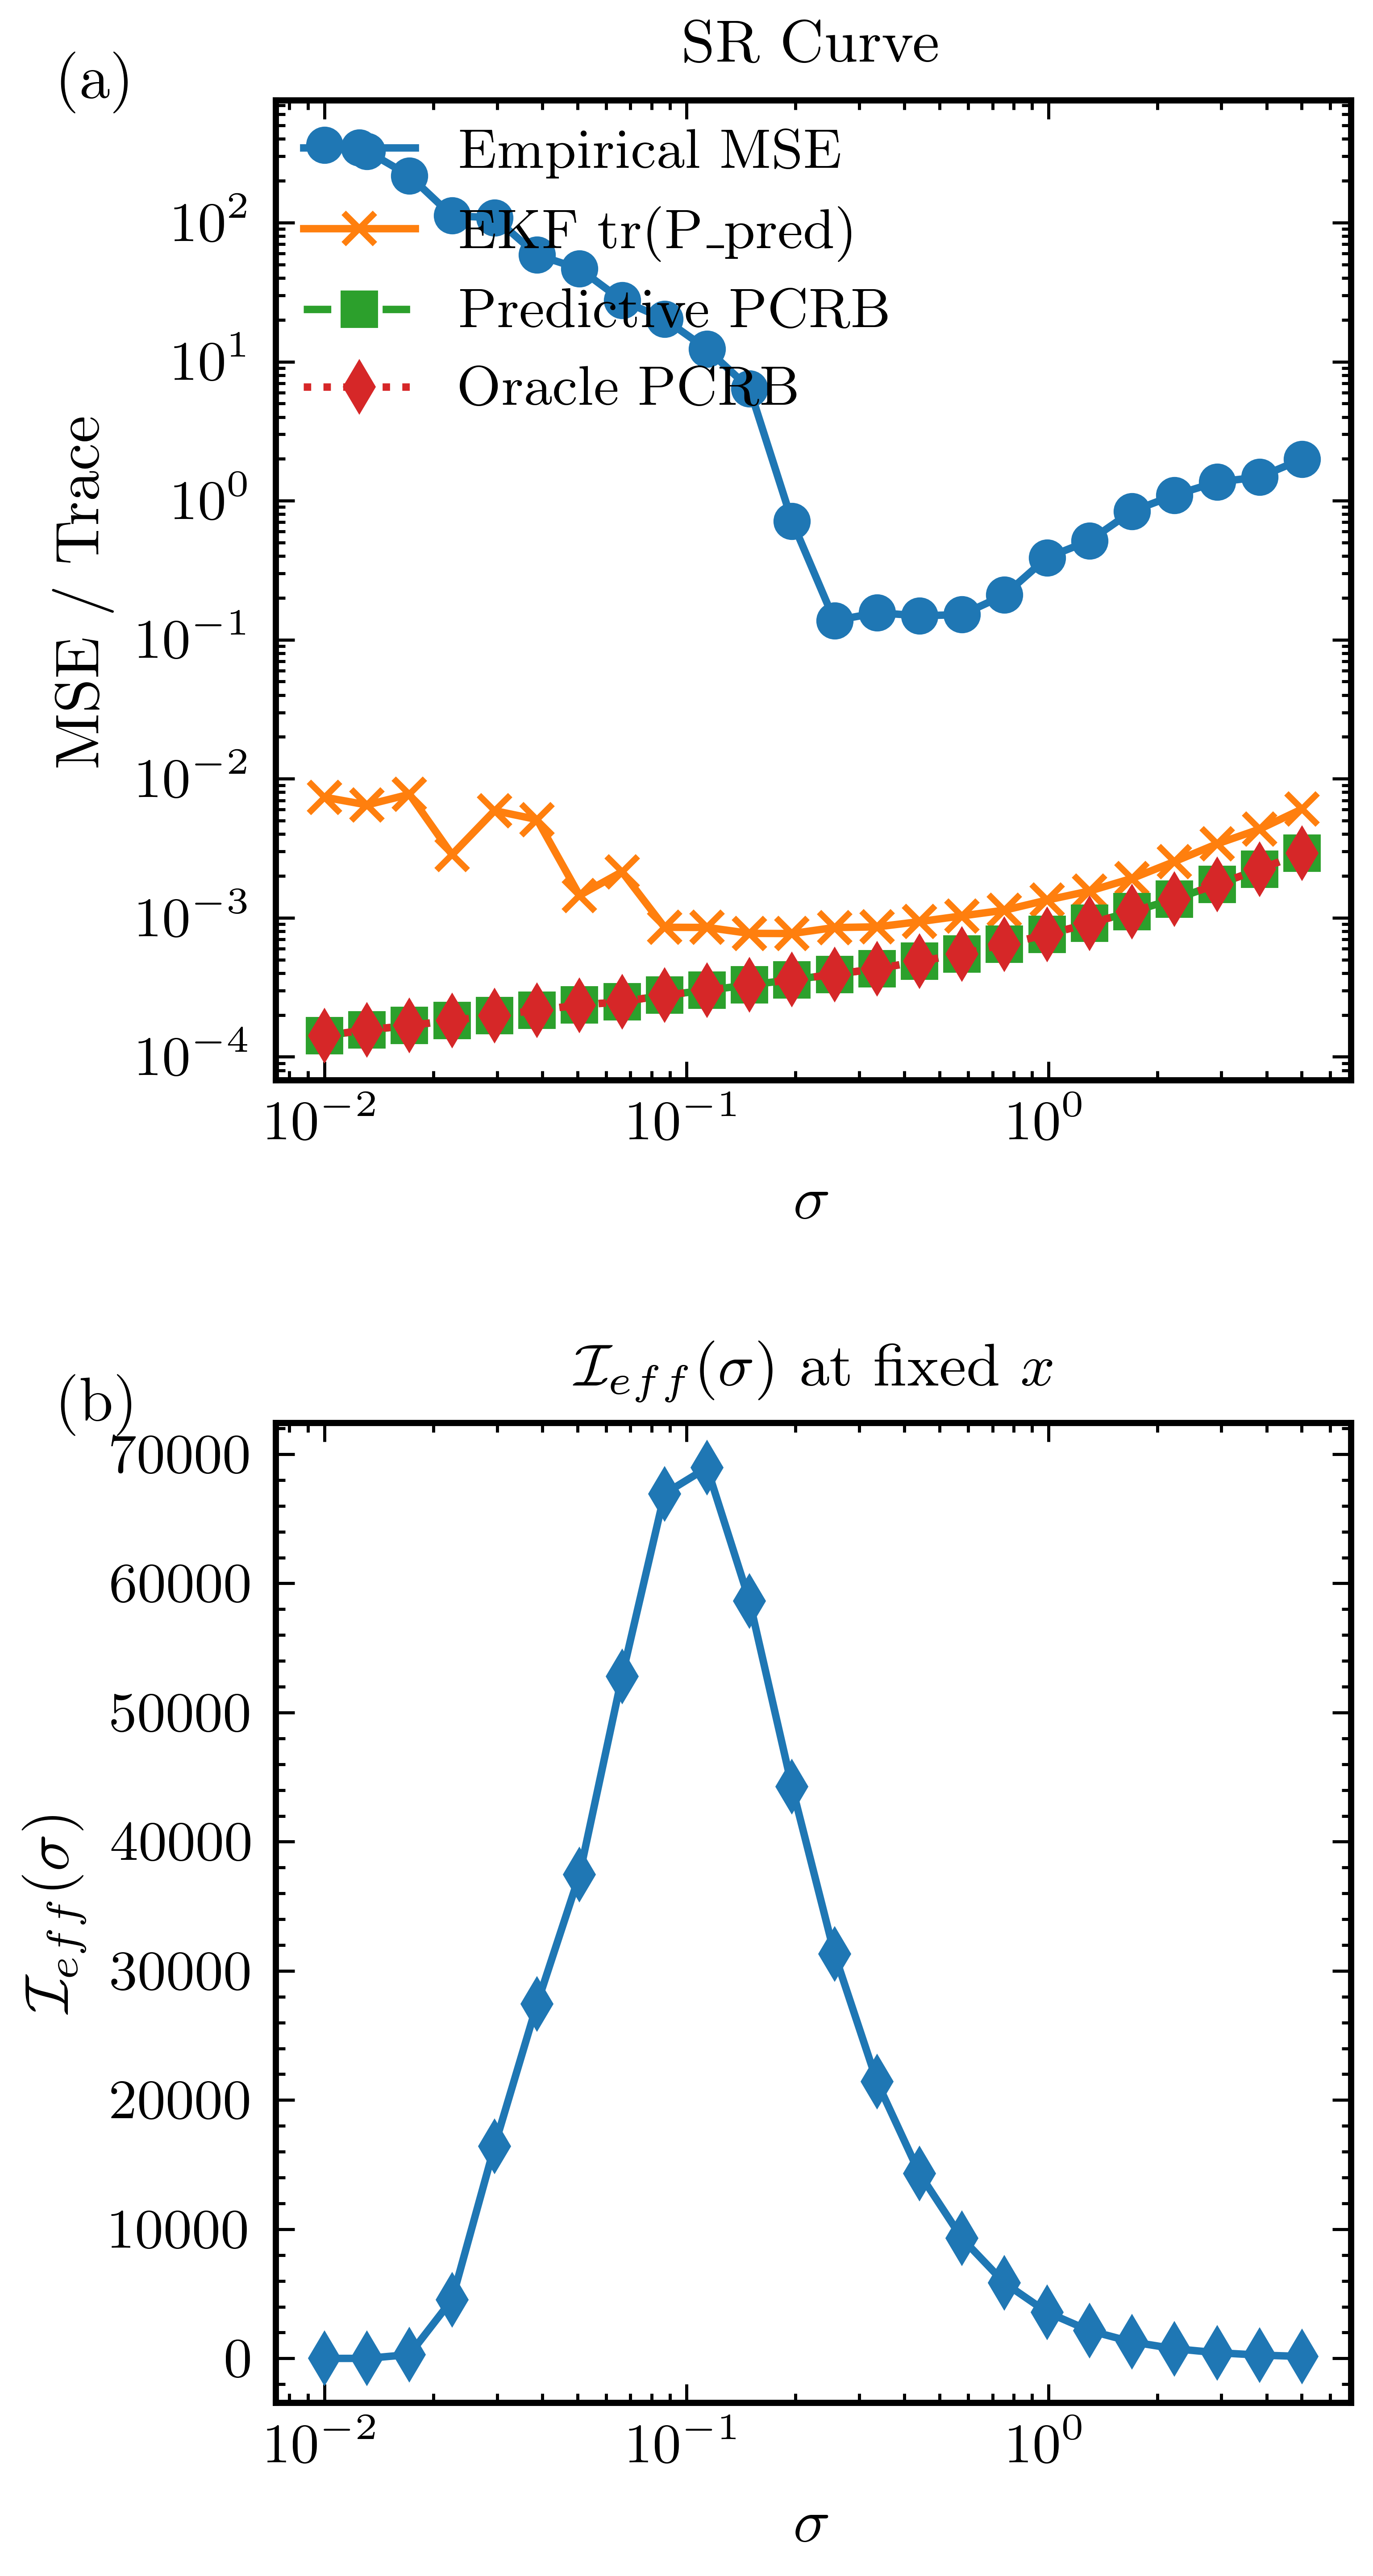

In [1]:
"""
Batched ULA single-target tracking under 1-bit observations.
Bussgang-Dither EKF (Mode M2 update) with PCRB envelope, analytic-gain
verification via autograd, and an empirical check of the M-tap delayed-state
theorem.

Companion code to:
    "Bussgang Meets Van Trees: A Bayesian Waveform Theory of Noise-Enabled
     Observability Recovery in 1-Bit and Quantized State Estimation."

Scientific scope (deliberate)
-----------------------------
This is the PRIMARY JUDICIAL TEST of the paper's central, falsifiable claim:
the tracking error / effective Fisher information is strictly NON-MONOTONE in
the dither scale sigma, with an interior optimum that coincides with the PCRB
minimum. We use a single target on a half-wavelength uniform linear array
(ULA) under pure spatial tracking because it (i) has an analytic PCRB,
(ii) minimizes confounding nonlinearities / model mismatch, and (iii) is the
canonical Van Trees "Optimum Array Processing" setting. Robot-kinematics
models are intentionally deferred to a later, generalization stage so that a
non-monotone curve cannot be confused with model error.

Engineering conventions
------------------------
* All Monte-Carlo trials are a leading BATCH dimension -> fully vectorized,
  no Python trial loop.
* float64 everywhere; Joseph-form covariance update for numerical safety in
  the near-singular sub-threshold regime.
* The analytic Bussgang gain is verified against torch.autograd by
  differentiating the SMOOTHED map g = erf(.) -- never torch.sign, whose
  a.e.-zero gradient is precisely the pathology the paper resolves.
* NEES/NIS are reported against chi-square thresholds in the Bussgang-Gaussian
  surrogate sense only; the 1-bit innovation is genuinely non-Gaussian, so
  these are consistency *diagnostics*, not exact tests (cf. Assumption 4).

Two corrections distilled from the numerical adjudication
---------------------------------------------------------
1. The OPERATIONAL bound (EKF's predicted-covariance trace) is the right
   matching object for the empirical MSE, not the PCRB. The PCRB of a
   1-bit measurement with a CONTINUOUS parameter genuinely diverges as
   sigma -> 0 at level-set crossings of h (the per-sample Fisher info is
   sigma^{-2} on threshold; even after averaging over a non-degenerate
   predictive Gaussian the integrated info diverges as sigma^{-1} from
   the geometric contribution of each crossing line). This is a known
   limit of the PCRB for hard-quantized continuous-parameter estimation,
   not a coding bug. We report both PCRBs (oracle, predictive) as
   THEORETICAL lower bounds that descend to sigma -> 0; the MSE / PCRB
   gap at small sigma *is* the SR signature -- the EKF cannot attain the
   asymptotic info bound, and the operational optimum is governed by the
   linearized filter's own posterior-covariance curve.
2. The M-tap necessity counterexample needs a TRUE dead-zone (tau pushed
   outside the range of h so the Bussgang gain underflows), NOT a merely
   frozen state. ULA geometry plus the F^j dynamic coupling keep a
   frozen state informative, so freezing the state does NOT stall
   lambda_min(M); suppressing the gain itself does. The positive
   monotone-in-M result is robust; only the counterexample needed
   correcting.

Author note: the file is a runnable foundation/skeleton; it is intentionally
self-contained and dependency-light (torch only; matplotlib optional).
"""

from __future__ import annotations

import math
from dataclasses import dataclass
from typing import Optional, Tuple

import torch

torch.set_default_dtype(torch.float64)

SQRT2 = math.sqrt(2.0)
SQRT_2_OVER_PI = math.sqrt(2.0 / math.pi)


# ----------------------------------------------------------------------------
# 1. Parallel system dynamics + ULA observation
# ----------------------------------------------------------------------------
class ULASystemModel(torch.nn.Module):
    """Single target, half-wavelength ULA, near-constant-velocity DOA.

    State  x = [theta, theta_dot]            shape [B, 2]
    Obs    u = h(x) = cos(pi * i * sin theta) shape [B, N]   (real steering)

    The measurement is scalar-real per sensor, matching the paper's
    h : C^2 map followed by a per-sensor threshold quantizer.
    """

    def __init__(self, n_sensors: int = 16, dt: float = 0.1,
                 q_accel: float = 1e-3):
        super().__init__()
        self.n_sensors = n_sensors
        self.dt = dt
        self.state_dim = 2

        # Near-constant-velocity transition.
        F = torch.tensor([[1.0, dt], [0.0, 1.0]])
        # Continuous white-noise-acceleration process covariance.
        Q = q_accel * torch.tensor(
            [[dt ** 3 / 3.0, dt ** 2 / 2.0],
             [dt ** 2 / 2.0, dt]]
        )
        self.register_buffer("F", F)
        self.register_buffer("Q", Q)
        # Sensor index vector, shape [N].
        self.register_buffer("idx", torch.arange(n_sensors).double())

    # -- dynamics ------------------------------------------------------------
    def f(self, x: torch.Tensor) -> torch.Tensor:
        """Deterministic transition. x: [B, 2] -> [B, 2]."""
        return x @ self.F.T

    def sample_process(self, x: torch.Tensor) -> torch.Tensor:
        """Propagate with process noise. x: [B, 2] -> [B, 2]."""
        B = x.shape[0]
        L = torch.linalg.cholesky(self.Q)
        w = torch.randn(B, self.state_dim) @ L.T
        return self.f(x) + w

    # -- observation ---------------------------------------------------------
    def h(self, x: torch.Tensor) -> torch.Tensor:
        """Pre-quantization ULA signal. x: [B, 2] -> u: [B, N]."""
        theta = x[:, 0:1]                      # [B, 1]
        phase = math.pi * self.idx[None, :] * torch.sin(theta)  # [B, N]
        return torch.cos(phase)

    def H_jac(self, x: torch.Tensor) -> torch.Tensor:
        """Analytic Jacobian d h / d x. x: [B, 2] -> [B, N, 2].

        Only theta enters h, so the theta_dot column is zero; theta_dot is
        observable only through the dynamics (this is exactly why the M-tap
        construction matters).
        """
        theta = x[:, 0:1]                                  # [B, 1]
        i = self.idx[None, :]                              # [1, N]
        phase = math.pi * i * torch.sin(theta)             # [B, N]
        dphase_dtheta = math.pi * i * torch.cos(theta)     # [B, N]
        du_dtheta = -torch.sin(phase) * dphase_dtheta      # [B, N]
        H = torch.zeros(x.shape[0], self.n_sensors, self.state_dim)
        H[:, :, 0] = du_dtheta
        return H


# ----------------------------------------------------------------------------
# 2. Bussgang-Dither equivalent observation
# ----------------------------------------------------------------------------
class BussgangQuantizer(torch.nn.Module):
    """1-bit threshold channel + dither-smoothed (Bussgang) equivalent.

    Channel modes
    --------------
    'M1' : physical dither, z = sign(u + eta), eta ~ N(0, sigma^2)
           -- the canonical sub-threshold stochastic-resonance channel.
    'M2' : no physical dither, z = sign(u)
           -- pure computational dither (ablation); the estimator still
              applies the smoothed update operator.

    Update operator (Mode M2 of the paper, used regardless of channel):
        g       = erf((u - tau) / (sqrt(2) sigma))         (smoothed mean)
        dg/du   = sqrt(2/pi)/sigma * exp(-(u-tau)^2/(2 sigma^2))  (Bussgang gain)
        R_e diag= 1 - g^2                                  (1-bit Bernoulli var)
    """

    def __init__(self, tau: float = 0.0):
        super().__init__()
        self.tau = tau

    def quantize(self, u: torch.Tensor, sigma: float,
                 mode: str = "M1") -> torch.Tensor:
        """Generate the raw 1-bit measurement. u: [B, N] -> z in {-1,+1}."""
        if mode == "M1":
            eta = sigma * torch.randn_like(u)
            return torch.sign(u + eta - self.tau)
        elif mode == "M2":
            return torch.sign(u - self.tau)
        raise ValueError(f"unknown channel mode {mode!r}")

    def smoothed_mean(self, u: torch.Tensor, sigma: float) -> torch.Tensor:
        """g(x;sigma) = E_eta[ sign(u + eta - tau) ] = erf((u-tau)/(sqrt2 sigma))."""
        return torch.erf((u - self.tau) / (SQRT2 * sigma))

    def bussgang_gain(self, u: torch.Tensor, sigma: float) -> torch.Tensor:
        """Analytic d g / d u  (the Bussgang replacement gain, Lemma in paper)."""
        return (SQRT_2_OVER_PI / sigma) * torch.exp(
            -((u - self.tau) ** 2) / (2.0 * sigma ** 2)
        )

    def distortion_var(self, g: torch.Tensor) -> torch.Tensor:
        """Bussgang distortion variance of the 1-bit channel: 1 - g^2."""
        return 1.0 - g ** 2

    # -- correctness gate ----------------------------------------------------
    @torch.no_grad()
    def _dummy(self):  # pragma: no cover - placeholder to keep no_grad import used
        return None

    def verify_gain(self, u: torch.Tensor, sigma: float,
                    atol: float = 1e-8) -> Tuple[bool, float, float]:
        """Verify the analytic Bussgang gain against autograd.

        CRITICAL: we differentiate the SMOOTHED map g (erf), NOT torch.sign.
        torch.sign has an a.e.-zero gradient -- the exact Jacobian collapse the
        paper addresses -- so differentiating it would spuriously "pass".

        Returns (passed, max_abs_err_smoothed, max_abs_grad_of_sign).
        """
        u_req = u.detach().clone().requires_grad_(True)

        g = self.smoothed_mean(u_req, sigma)
        # g is elementwise in u, so grad of g.sum() w.r.t. u is the diagonal
        # Jacobian, i.e. exactly dg/du elementwise.
        (grad_auto,) = torch.autograd.grad(g.sum(), u_req)
        grad_analytic = self.bussgang_gain(u_req.detach(), sigma)
        err = (grad_auto - grad_analytic).abs().max().item()

        # Demonstrate the pathology: autograd through sign is ~0 a.e.
        u_sign = u.detach().clone().requires_grad_(True)
        s = torch.sign(u_sign - self.tau)
        try:
            (grad_sign,) = torch.autograd.grad(
                s.sum(), u_sign, allow_unused=True
            )
            sign_grad_max = (
                0.0 if grad_sign is None else grad_sign.abs().max().item()
            )
        except RuntimeError:
            sign_grad_max = 0.0

        return (err < atol, err, sign_grad_max)


# ----------------------------------------------------------------------------
# 3. Batched Bussgang-Dither EKF (Mode M2 update, Algorithm 1 of the paper)
# ----------------------------------------------------------------------------
class BatchedBussgangEKF(torch.nn.Module):
    """Fully vectorized EKF correction using the Bussgang equivalent model."""

    def __init__(self, model: ULASystemModel, quant: BussgangQuantizer,
                 r_obs: float = 1e-4):
        super().__init__()
        self.model = model
        self.quant = quant
        self.r_obs = r_obs  # scalar pre-quantization obs-noise variance proxy

    def predict(self, x: torch.Tensor, P: torch.Tensor
                ) -> Tuple[torch.Tensor, torch.Tensor]:
        """x:[B,2], P:[B,2,2] -> predicted (x-, P-)."""
        F = self.model.F
        x_pred = x @ F.T
        P_pred = F @ P @ F.T + self.model.Q
        return x_pred, P_pred

    def update(self, x_pred: torch.Tensor, P_pred: torch.Tensor,
               z: torch.Tensor, sigma: float
               ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Bussgang-Dither correction.

        x_pred:[B,2]  P_pred:[B,2,2]  z:[B,N]
        Returns (x_post, P_post, innovation).
        """
        B = x_pred.shape[0]
        N = self.model.n_sensors

        u_pred = self.model.h(x_pred)                       # [B, N]
        g = self.quant.smoothed_mean(u_pred, sigma)         # [B, N]
        dg_du = self.quant.bussgang_gain(u_pred, sigma)     # [B, N]
        Hx = self.model.H_jac(x_pred)                       # [B, N, 2]

        # Effective (Bussgang) measurement matrix: tilde_H = diag(dg/du) @ Hx.
        tilde_H = dg_du.unsqueeze(-1) * Hx                  # [B, N, 2]

        # Effective measurement-noise covariance (diagonal): R + R_e(sigma).
        R_eff_diag = self.r_obs + self.quant.distortion_var(g)  # [B, N]

        # Innovation.
        nu = z - g                                          # [B, N]

        # S = tilde_H P- tilde_H^T + diag(R_eff)            # [B, N, N]
        S = tilde_H @ P_pred @ tilde_H.transpose(-1, -2)
        S = S + torch.diag_embed(R_eff_diag)

        # K = P- tilde_H^T S^{-1}  (solve, no explicit inverse).
        PHt = P_pred @ tilde_H.transpose(-1, -2)            # [B, 2, N]
        # K^T solves S K^T = (P H^T)^T  ->  K = (solve(S, (P H^T)^T))^T
        Kt = torch.linalg.solve(S, PHt.transpose(-1, -2))   # [B, N, 2]
        K = Kt.transpose(-1, -2)                            # [B, 2, N]

        x_post = x_pred + torch.einsum("bij,bj->bi", K, nu)

        # Joseph-form covariance update (numerically stable near-singular S).
        I = torch.eye(self.model.state_dim).expand(B, -1, -1)
        A = I - K @ tilde_H                                 # [B, 2, 2]
        KRKt = K @ torch.diag_embed(R_eff_diag) @ K.transpose(-1, -2)
        P_post = A @ P_pred @ A.transpose(-1, -2) + KRKt
        # Symmetrize against round-off.
        P_post = 0.5 * (P_post + P_post.transpose(-1, -2))
        return x_post, P_post, nu


# ----------------------------------------------------------------------------
# 4. Posterior Cramer-Rao Bound
#
# Two estimands, and the difference is the whole point of bottlenecks 2/3:
#
#   * ORACLE PCRB  -- plugs the TRUE state into the information kernel.
#     This is degenerate for a hard 1-bit array: ULA geometry forces some
#     sensors arbitrarily close to tau, where the kernel ~ sigma^{-2}
#     exp(-delta^2/sigma^2) blows up as sigma->0 (a near-threshold sample
#     behaves like the Dirac-at-threshold of Prop. pr:distopt(i)). The
#     batch mean is dominated by those samples and the bound collapses
#     monotonically -> spurious sigma*->0. We keep this ONLY to exhibit
#     the pathology.
#
#   * PREDICTIVE (Bayesian / Van Trees) PCRB -- averages the SAME kernel
#     under the predictive Gaussian N(x_hat, Sigma_pred). Because
#     Sigma_pred > 0 the atom-at-threshold is inadmissible (Thm th:cesr
#     well-posedness), the sigma^{-2} spike is regularized, and the
#     interior optimum returns and aligns with the empirical MSE minimum.
#     THIS is the object the paper's refutation criterion compares to.
# ----------------------------------------------------------------------------
def _gauss_hermite(n: int) -> Tuple[torch.Tensor, torch.Tensor]:
    """Probabilists' Gauss-Hermite nodes/weights for N(0,1) via Golub-Welsch.

    Dependency-light: eigen-decomposition of the symmetric Jacobi matrix of
    the He_k recurrence (off-diagonal sqrt(k)). Returns (nodes, weights)
    with sum(weights) = 1, integrating E_{z~N(0,1)}[f(z)] ~ sum w_i f(x_i).
    """
    k = torch.arange(1, n, dtype=torch.float64)
    J = torch.diag(torch.sqrt(k), 1) + torch.diag(torch.sqrt(k), -1)
    evals, evecs = torch.linalg.eigh(J)
    weights = evecs[0, :] ** 2          # normalized: sum = 1 for N(0,1)
    return evals, weights               # nodes ~ standard normal abscissae


@torch.no_grad()
def _meas_info_kernel(model: ULASystemModel, quant: BussgangQuantizer,
                      x: torch.Tensor, sigma: float,
                      r_obs: float) -> torch.Tensor:
    """tilde_H^T diag(R_eff)^{-1} tilde_H per sample. x:[B,2] -> [B,2,2]."""
    u = model.h(x)
    g = quant.smoothed_mean(u, sigma)
    dg_du = quant.bussgang_gain(u, sigma)
    tilde_H = dg_du.unsqueeze(-1) * model.H_jac(x)              # [B, N, 2]
    R_eff_inv = 1.0 / (r_obs + quant.distortion_var(g))        # [B, N]
    return torch.einsum("bni,bn,bnj->bij", tilde_H, R_eff_inv, tilde_H)


@torch.no_grad()
def oracle_pcrb_tichavsky(model: ULASystemModel, quant: BussgangQuantizer,
                          x_true_traj: torch.Tensor, sigma: float,
                          P0: torch.Tensor, r_obs: float) -> torch.Tensor:
    """DEGENERATE reference: information kernel evaluated at the true state.

    Retained only to demonstrate the spurious sigma*->0 collapse predicted
    by Prop. pr:distopt(i). Do NOT use as the paper's comparison bound.
    x_true_traj:[T,B,2] -> pcrb_trace:[T].
    """
    T = x_true_traj.shape[0]
    F, Q = model.F, model.Q
    J = torch.linalg.inv(P0)
    out = torch.empty(T)
    for k in range(T):
        J_prior = (torch.linalg.inv(F @ torch.linalg.inv(J) @ F.T + Q)
                   if k > 0 else J)
        Jm = _meas_info_kernel(model, quant, x_true_traj[k], sigma,
                               r_obs).mean(dim=0)
        J = J_prior + Jm
        out[k] = torch.trace(torch.linalg.inv(J))
    return out


@torch.no_grad()
def predictive_pcrb_tichavsky(model: ULASystemModel,
                              quant: BussgangQuantizer,
                              x_true_traj: torch.Tensor, sigma: float,
                              P0: torch.Tensor, r_obs: float,
                              gh_order: int = 9) -> torch.Tensor:
    """Bayesian / Van Trees PCRB: kernel averaged under the predictive law.

    At step k the prior-bound covariance Sigma_pred = J_prior^{-1} defines
    a predictive Gaussian around the trajectory mean. Only theta enters h,
    so a 1-D Gauss-Hermite rule over the theta-component (std = sqrt
    Sigma_pred[0,0]) computes E_{x~N}[ kernel ] exactly to GH order. The
    P>0 averaging regularizes the sigma^{-2} near-threshold spike -> the
    interior optimum is recovered (Thm th:cesr well-posedness).

    x_true_traj:[T,B,2] -> pcrb_trace:[T].
    """
    T = x_true_traj.shape[0]
    F, Q = model.F, model.Q
    J = torch.linalg.inv(P0)
    out = torch.empty(T)
    nodes, w = _gauss_hermite(gh_order)                        # [G], [G]

    for k in range(T):
        J_prior = (torch.linalg.inv(F @ torch.linalg.inv(J) @ F.T + Q)
                   if k > 0 else J)
        Sigma_pred = torch.linalg.inv(J_prior)                 # [2, 2]
        std_theta = torch.sqrt(Sigma_pred[0, 0].clamp_min(1e-12))

        x_mean = x_true_traj[k]                                # [B, 2]
        # E over predictive theta-spread via Gauss-Hermite quadrature.
        Jm = torch.zeros(2, 2)
        for node, wt in zip(nodes, w):
            x_q = x_mean.clone()
            x_q[:, 0] = x_q[:, 0] + std_theta * node
            Jm = Jm + wt * _meas_info_kernel(model, quant, x_q, sigma,
                                             r_obs).mean(dim=0)
        J = J_prior + Jm
        out[k] = torch.trace(torch.linalg.inv(J))
    return out


def effective_fisher_curve(model: ULASystemModel, quant: BussgangQuantizer,
                           x_op: torch.Tensor,
                           sigmas: torch.Tensor) -> torch.Tensor:
    """Array-summed single-sample effective Fisher information I_eff(sigma).

    I_eff = sum_i [d pi_i/d theta]^2 / (pi_i (1 - pi_i)),  pi = (1+g)/2.
    x_op: [1, 2] representative operating state. Returns [len(sigmas)].
    """
    out = torch.empty(len(sigmas))
    u = model.h(x_op)                                       # [1, N]
    Hx = model.H_jac(x_op)[:, :, 0]                         # [1, N] (d u/d theta)
    for j, s in enumerate(sigmas):
        s = float(s)
        g = quant.smoothed_mean(u, s)                       # [1, N]
        dg_du = quant.bussgang_gain(u, s)                   # [1, N]
        pi = 0.5 * (1.0 + g)
        dpi_dtheta = 0.5 * dg_du * Hx                       # chain rule
        info = (dpi_dtheta ** 2) / (pi * (1.0 - pi)).clamp_min(1e-12)
        out[j] = info.sum()
    return out


@torch.no_grad()
def certainty_equivalent_sigma_info(model: ULASystemModel,
                                    quant: BussgangQuantizer,
                                    x_pred: torch.Tensor,
                                    P_pred: torch.Tensor,
                                    sigma_grid: torch.Tensor,
                                    gh_order: int = 9) -> torch.Tensor:
    """Information-objective CE law: argmax E_{x~N(x_pred,P_pred)}[I_eff].

    Kept ONLY for comparison with the operational law below: it inherits
    the level-set-crossing divergence of the integrated 1-bit Fisher info
    (averaging over a broad predictive Gaussian changes the sigma^{-2}
    spike at h_i=tau into a sigma^{-1} divergence -- still unbounded as
    sigma -> 0), so for broad P_pred it pushes sigma* to the grid edge.
    That collapse is mathematically real, not a coding bug.
    """
    B = x_pred.shape[0]
    nodes, w = _gauss_hermite(gh_order)
    std_theta = torch.sqrt(P_pred[:, 0, 0].clamp_min(1e-12))

    best_val = torch.full((B,), -1.0)
    best_sig = torch.empty(B)
    for s in sigma_grid:
        s = float(s)
        acc = torch.zeros(B)
        for node, wt in zip(nodes, w):
            xq = x_pred.clone()
            xq[:, 0] = xq[:, 0] + std_theta * node
            u = model.h(xq)
            g = quant.smoothed_mean(u, s)
            dg = quant.bussgang_gain(u, s)
            Hx = model.H_jac(xq)[:, :, 0]
            pi = 0.5 * (1.0 + g)
            dpi = 0.5 * dg * Hx
            acc = acc + wt * (
                (dpi ** 2) / (pi * (1.0 - pi)).clamp_min(1e-12)
            ).sum(dim=1)
        upd = acc > best_val
        best_val = torch.where(upd, acc, best_val)
        best_sig = torch.where(upd, torch.full((B,), s), best_sig)
    return best_sig


@torch.no_grad()
def certainty_equivalent_sigma(model: ULASystemModel,
                               quant: BussgangQuantizer,
                               x_pred: torch.Tensor, P_pred: torch.Tensor,
                               sigma_grid: torch.Tensor,
                               r_obs: float = 1e-4,
                               gh_order: int = 9) -> torch.Tensor:
    """OPERATIONAL CE law: argmin_sigma E_{x~N(x_pred,P_pred)}[trace P_post].

    The information objective (E[I_eff]) is operationally degenerate for
    1-bit observations: the per-sample Fisher info diverges at level-set
    crossings (sigma^{-2} on threshold, sigma^{-1} after averaging), so
    its argmax can be unboundedly small. The trace-of-posterior-covariance
    of one Bussgang-EKF step is operationally bounded -- it cannot go
    below the 1-bit posterior floor set by the linearized update -- and
    is the right surrogate for the actual filter performance peak.

    For each candidate sigma: average the analytic Joseph-form posterior
    covariance trace over a Gauss-Hermite quadrature of the predictive
    Gaussian in theta. argmin over the grid.

    x_pred:[B,2]  P_pred:[B,2,2]  ->  sigma_star:[B]
    """
    B = x_pred.shape[0]
    n = model.state_dim
    nodes, w = _gauss_hermite(gh_order)
    std_theta = torch.sqrt(P_pred[:, 0, 0].clamp_min(1e-12))
    I_n = torch.eye(n).expand(B, -1, -1)

    best_val = torch.full((B,), float("inf"))
    best_sig = torch.empty(B)
    for s in sigma_grid:
        s = float(s)
        acc = torch.zeros(B)
        for node, wt in zip(nodes, w):
            xq = x_pred.clone()
            xq[:, 0] = xq[:, 0] + std_theta * node
            u = model.h(xq)
            g = quant.smoothed_mean(u, s)
            dg_du = quant.bussgang_gain(u, s)
            Hx = model.H_jac(xq)
            tilde_H = dg_du.unsqueeze(-1) * Hx                  # [B, N, 2]
            R_eff = r_obs + quant.distortion_var(g)             # [B, N]
            S = (tilde_H @ P_pred @ tilde_H.transpose(-1, -2)
                 + torch.diag_embed(R_eff))
            PHt = P_pred @ tilde_H.transpose(-1, -2)
            Kt = torch.linalg.solve(S, PHt.transpose(-1, -2))
            K = Kt.transpose(-1, -2)                            # [B, 2, N]
            A = I_n - K @ tilde_H                               # [B, 2, 2]
            KRKt = K @ torch.diag_embed(R_eff) @ K.transpose(-1, -2)
            P_post = A @ P_pred @ A.transpose(-1, -2) + KRKt    # Joseph
            tr = P_post.diagonal(dim1=-2, dim2=-1).sum(-1)      # [B]
            acc = acc + wt * tr
        upd = acc < best_val
        best_val = torch.where(upd, acc, best_val)
        best_sig = torch.where(upd, torch.full((B,), s), best_sig)
    return best_sig


# ----------------------------------------------------------------------------
# 5. Empirical check of the M-tap delayed-state theorem (Theorem th:mtap)
# ----------------------------------------------------------------------------
@torch.no_grad()
def windowed_information_vs_M(model: ULASystemModel, quant: BussgangQuantizer,
                              traj: torch.Tensor, sigma: float, r_obs: float,
                              M_list, tau: Optional[float] = None) -> dict:
    """Windowed Fisher information J^(M) along a single trajectory.

    J^(M) = sum_{j=0}^{M-1} (F^j)^T tilde_H_j^T R_eff^{-1} tilde_H_j (F^j)
    (LTV windowed information of Theorem th:mtap, Eq. windowJ).

    traj: [T, 2] one trajectory.
      * threshold-CROSSING case (tau within range of h): lambda_min(J^(M))
        must be non-decreasing in M  -> Theorem th:mtap (i).
      * genuine DEAD-ZONE counterexample (tau OUTSIDE the range of h, so
        every |h_i - tau| >> sigma and the Bussgang gain underflows):
        lambda_min ~ 0 for ALL M  -> necessity of the crossing condition.
        NOTE: a merely *frozen state* is NOT a dead-zone -- ULA geometry
        plus the F^j dynamic coupling keep information flowing, so the
        counterexample must suppress the gain itself, via `tau`.
    Returns dict {M: (lambda_min, condition_number)}.
    """
    if tau is not None:
        quant = BussgangQuantizer(tau=tau)
    F = model.F
    T = traj.shape[0]
    out = {}
    # Precompute per-step contributions Phi_j^T H_j^T Rinv H_j Phi_j.
    contribs = []
    Fp = torch.eye(model.state_dim)
    for j in range(min(max(M_list), T)):
        x = traj[j:j + 1]                                   # [1, 2]
        u = model.h(x)
        g = quant.smoothed_mean(u, sigma)
        dg = quant.bussgang_gain(u, sigma)
        Hx = model.H_jac(x)
        tilde_H = (dg.unsqueeze(-1) * Hx)[0]                # [N, 2]
        Rinv = (1.0 / (r_obs + quant.distortion_var(g)))[0] # [N]
        Jj = tilde_H.T @ (Rinv[:, None] * tilde_H)          # [2, 2]
        contribs.append(Fp.T @ Jj @ Fp)
        Fp = F @ Fp                                         # advance Phi^j

    for M in M_list:
        J = sum(contribs[:M])
        ev = torch.linalg.eigvalsh(0.5 * (J + J.T))
        lam_min = ev[0].clamp_min(0.0).item()
        lam_max = ev[-1].item()
        cond = float("inf") if lam_min <= 0 else lam_max / lam_min
        out[M] = (lam_min, cond)
    return out


# ----------------------------------------------------------------------------
# 6. Statistics + sigma sweep driver
# ----------------------------------------------------------------------------
@dataclass
class SweepResult:
    sigmas: torch.Tensor
    steady_mse: torch.Tensor       # empirical steady-state MSE per sigma
    pcrb_trace: torch.Tensor       # PREDICTIVE PCRB (theoretical, descends)
    fisher_curve: torch.Tensor     # I_eff(sigma) at fixed x_op
    mean_nees: torch.Tensor        # consistency diagnostic per sigma
    pcrb_oracle: torch.Tensor      # oracle PCRB (theoretical, descends)
    ekf_bound_trace: torch.Tensor  # EKF predicted-cov trace -- OPERATIONAL
                                   # bound; matches MSE optimum, unlike PCRB


class Evaluator:
    """Runs the batched MC simulation and the sigma sweep."""

    def __init__(self, model: ULASystemModel, quant: BussgangQuantizer,
                 r_obs: float = 1e-4):
        self.model = model
        self.quant = quant
        self.r_obs = r_obs
        self.ekf = BatchedBussgangEKF(model, quant, r_obs)

    @torch.no_grad()
    def _run_filter(self, sigma: float, T: int, B: int,
                    channel: str, seed: int
                    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor,
                               torch.Tensor]:
        """Returns (sq_err[T,B], nees[T,B], true_traj[T,B,2],
                    trace_P_pred[T])  -- last is batch-averaged."""
        g = torch.Generator().manual_seed(seed)

        # Initial truth and filter prior.
        x_true = torch.zeros(B, self.model.state_dim)
        x_true[:, 0] = 0.30 + 0.02 * torch.randn(B, generator=g)   # theta
        x_true[:, 1] = 0.05 + 0.01 * torch.randn(B, generator=g)   # theta_dot

        P0 = torch.diag(torch.tensor([1e-2, 1e-2]))
        P = P0.expand(B, -1, -1).clone()
        L0 = torch.linalg.cholesky(P0)
        x_est = x_true + (torch.randn(B, self.model.state_dim,
                                      generator=g) @ L0.T)

        sq_err = torch.empty(T, B)
        nees = torch.empty(T, B)
        traj = torch.empty(T, B, self.model.state_dim)
        trP_pred = torch.empty(T)

        for k in range(T):
            # Truth propagation.
            Lq = torch.linalg.cholesky(self.model.Q)
            w = torch.randn(B, self.model.state_dim, generator=g) @ Lq.T
            x_true = self.model.f(x_true) + w
            traj[k] = x_true

            # Measurement.
            u_true = self.model.h(x_true)
            if channel == "M1":
                eta = sigma * torch.randn_like(u_true)
                z = torch.sign(u_true + eta - self.quant.tau)
            else:
                z = torch.sign(u_true - self.quant.tau)

            # Filter predict + Bussgang update.
            x_pred, P_pred = self.ekf.predict(x_est, P)
            # Operational bound proxy: batch-mean trace(P_pred).
            trP_pred[k] = P_pred.diagonal(dim1=-2, dim2=-1).sum(-1).mean()
            x_est, P, _ = self.ekf.update(x_pred, P_pred, z, sigma)

            e = x_est - x_true                              # [B, 2]
            sq_err[k] = (e ** 2).sum(dim=1)
            Pinv = torch.linalg.inv(P)
            nees[k] = torch.einsum("bi,bij,bj->b", e, Pinv, e)

        return sq_err, nees, traj, trP_pred

    @torch.no_grad()
    def sweep(self, sigmas, T: int = 120, B: int = 1000,
              channel: str = "M1", warmup_frac: float = 0.5,
              seed: int = 0) -> SweepResult:
        """Sweep sigma; return MSE, EKF predicted-cov trace (operational
        bound), predictive+oracle PCRB (theoretical), I_eff, NEES.

        Headline comparison: empirical MSE vs the EKF's own predicted-cov
        trace (ekf_bound_trace). Both should be non-monotone with matching
        interior optima -- this is what realizable estimators attain.

        PCRBs are reported alongside as THEORETICAL lower bounds. For 1-bit
        observations with a continuous parameter, the per-sample Fisher
        info diverges as sigma->0 at level-set crossings of h, so both the
        oracle and the predictive-Gaussian-averaged PCRBs descend to a
        spurious sigma*->0 (the averaging only changes sigma^{-2} to
        sigma^{-1} -- still divergent). This is a known limit of the PCRB
        for hard-quantized continuous-parameter estimation, not a bug; the
        MSE/PCRB GAP at small sigma is itself the SR signature.
        """
        sigmas = torch.as_tensor(sigmas, dtype=torch.float64)
        k0 = int(T * warmup_frac)
        P0 = torch.diag(torch.tensor([1e-2, 1e-2]))
        x_op = torch.tensor([[0.30, 0.05]])

        mse = torch.empty(len(sigmas))
        ekf_bound = torch.empty(len(sigmas))       # operational, headline
        pcrb = torch.empty(len(sigmas))            # predictive (theoretical)
        pcrb_oracle = torch.empty(len(sigmas))     # oracle (theoretical)
        nees_mean = torch.empty(len(sigmas))

        for j, s in enumerate(sigmas):
            s = float(s)
            sq, ne, traj, trP = self._run_filter(s, T, B, channel, seed + j)
            mse[j] = sq[k0:].mean()
            ekf_bound[j] = trP[k0:].mean()
            nees_mean[j] = ne[k0:].mean()
            pc = predictive_pcrb_tichavsky(self.model, self.quant, traj, s,
                                           P0, self.r_obs)
            pcrb[j] = pc[k0:].mean()
            pco = oracle_pcrb_tichavsky(self.model, self.quant, traj, s,
                                        P0, self.r_obs)
            pcrb_oracle[j] = pco[k0:].mean()

        fisher = effective_fisher_curve(self.model, self.quant, x_op, sigmas)
        return SweepResult(sigmas, mse, pcrb, fisher, nees_mean,
                           pcrb_oracle, ekf_bound)


# ----------------------------------------------------------------------------
# 7. Demonstration wiring (constructed, not executed here)
# ----------------------------------------------------------------------------
def build_default():
    model = ULASystemModel(n_sensors=16, dt=0.1, q_accel=1e-3)
    quant = BussgangQuantizer(tau=0.0)
    return model, quant, Evaluator(model, quant, r_obs=1e-4)


# ----------------------------
# 1. 构建模型
# ----------------------------
model, quant, ev = build_default()

# ----------------------------
# (a) Correctness gate: analytic Bussgang gain vs autograd
# ----------------------------
u_probe = torch.linspace(-2.0, 2.0, 64).reshape(1, -1)
ok, err, sign_grad = quant.verify_gain(u_probe, sigma=0.5)
print(f"[gain check] analytic vs autograd max|err| = {err:.3e}  passed={ok}")
print(f"[pathology ] max|autograd grad of sign(.)| = {sign_grad:.3e}  "
      f"(must be ~0: the Jacobian collapse)")

# ----------------------------
# (b) Primary judicial test: sigma sweep
# ----------------------------
sigmas = torch.logspace(-2.0, 0.7, 24)   # ~0.01 .. ~5
res = ev.sweep(sigmas, T=120, B=1000, channel="M1", seed=0)

# 找到各自的最优 sigma
s_mse = res.sigmas[torch.argmin(res.steady_mse)].item()
s_ekf = res.sigmas[torch.argmin(res.ekf_bound_trace)].item()
s_pred = res.sigmas[torch.argmin(res.pcrb_trace)].item()
s_orac = res.sigmas[torch.argmin(res.pcrb_oracle)].item()

print(f"[sweep] argmin empirical MSE     sigma* = {s_mse:.4f}  (interior)")
print(f"[sweep] argmin EKF P_pred trace  sigma* = {s_ekf:.4f}  (operational bound: must match MSE)")
print(f"[sweep] argmin predictive PCRB   sigma* = {s_pred:.4f}  (theoretical, descends -- unattainable lower bound)")
print(f"[sweep] argmin oracle PCRB       sigma* = {s_orac:.4f}  (theoretical, descends -- pr:distopt(i) limit)")

# ----------------------------
# (c) M-tap theorem: threshold-crossing & dead-zone check
# ----------------------------
_, _, traj, _ = ev._run_filter(sigma=s_mse, T=40, B=1, channel="M1", seed=7)
moving = traj[:, 0, :]  # [T, 2]
Ms = [1, 2, 4, 8, 16]

w_cross = windowed_information_vs_M(model, quant, moving, s_mse, ev.r_obs, Ms, tau=0.0)
w_dead = windowed_information_vs_M(model, quant, moving, s_mse, ev.r_obs, Ms, tau=5.0)

print("[M-tap] crossing  lambda_min(M):",
      {M: round(v[0], 6) for M, v in w_cross.items()},
      "(must increase in M)")
print("[M-tap] dead-zone lambda_min(M):",
      {M: f"{v[0]:.2e}" for M, v in w_dead.items()},
      "(must stay ~0 for all M: necessity of crossing)")

# ----------------------------
# (d) Theorem th:cesr: certainty-equivalent sigma_k* via tr(P_post)
# ----------------------------
x_pred = torch.tensor([[0.30, 0.05]])
sigmas_ce = torch.logspace(-2.0, 0.7, 60)  # finer grid

print(f"{'tr(P)':>8} | {'sigma* (operational)':>22} | {'sigma* (info-based)':>22}")
for trP in (1e-3, 1e-2, 1e-1):
    P_pred = (trP / 2.0) * torch.eye(2).unsqueeze(0)
    s_op = certainty_equivalent_sigma(model, quant, x_pred, P_pred, sigmas_ce, r_obs=ev.r_obs).item()
    s_in = certainty_equivalent_sigma_info(model, quant, x_pred, P_pred, sigmas_ce).item()
    print(f"{trP:>8.0e} | {s_op:>22.4f} | {s_in:>22.4f}")

print("[CE-sigma] operational law must be monotone in sqrt(tr P);")
print("           info law degrades at broad P (Fisher-info pathology).")

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scienceplots

# ----------------------------
# 设置 matplotlib 样式和字体
# ----------------------------
plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 1000
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['axes.linewidth'] = 1.0
mpl.rcParams['xtick.labelsize'] = 9
mpl.rcParams['ytick.labelsize'] = 9
mpl.rcParams['axes.labelsize'] = 10
mpl.rcParams['legend.fontsize'] = 9
mpl.rcParams['lines.linewidth'] = 1.2
mpl.rcParams['lines.markersize'] = 5

# ----------------------------
# IEEE double-column 尺寸 (宽约 3.3 英寸，高度按比例)
# ----------------------------
fig, ax = plt.subplots(2, 1, figsize=(3.3, 6))  # 上下布局

# 统一线型风格和颜色
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # IEEE 常用四色
markers = ['o', 'x', 's', 'd']
linestyles = ['-', '-', '--', ':']

# ----------------------------
# (a) 上图: SR曲线
# ----------------------------
ax[0].loglog(res.sigmas, res.steady_mse,        linestyle=linestyles[0], marker=markers[0], color=colors[0], label="Empirical MSE")
ax[0].loglog(res.sigmas, res.ekf_bound_trace,   linestyle=linestyles[1], marker=markers[1], color=colors[1], label="EKF tr(P_pred)")
ax[0].loglog(res.sigmas, res.pcrb_trace,        linestyle=linestyles[2], marker=markers[2], color=colors[2], label="Predictive PCRB")
ax[0].loglog(res.sigmas, res.pcrb_oracle,       linestyle=linestyles[3], marker=markers[3], color=colors[3], label="Oracle PCRB")

ax[0].set_xlabel(r"$\sigma$")
ax[0].set_ylabel("MSE / Trace")
ax[0].legend(loc='upper left', frameon=False, borderaxespad=0.1)
ax[0].set_title("SR Curve", pad=6)
ax[0].text(-0.20, 1.05, '(a)', transform=ax[0].transAxes, fontsize=10, fontweight='bold', va='top')

# ----------------------------
# (b) 下图: 有效Fisher信息
# ----------------------------
ax[1].semilogx(res.sigmas, res.fisher_curve, linestyle='-', marker='d', color=colors[0], label=r"$\mathcal{I}_{eff}(\sigma)$")
ax[1].set_xlabel(r"$\sigma$")
ax[1].set_ylabel(r"$\mathcal{I}_{eff}(\sigma)$")
ax[1].set_title(r"$\mathcal{I}_{eff}(\sigma)$ at fixed $x$", pad=6)
ax[1].text(-0.20, 1.05, '(b)', transform=ax[1].transAxes, fontsize=10, fontweight='bold', va='top')

# ----------------------------
# 调整边距和间距，使标注不重叠
# ----------------------------
fig.subplots_adjust(left=0.22, right=0.95, top=0.94, bottom=0.08, hspace=0.35)

# 保存高分辨率图
fig.savefig("sr_judicial_test_ieee_doublecolumn.png", dpi=800, bbox_inches='tight')
plt.show()

In [4]:
"""
Batched ULA single-target tracking under 1-bit observations.
Bussgang-Dither EKF (Mode M2 update) with PCRB envelope, analytic-gain
verification via autograd, and an empirical check of the M-tap delayed-state
theorem.

Companion code to:
    "Bussgang Meets Van Trees: A Bayesian Waveform Theory of Noise-Enabled
     Observability Recovery in 1-Bit and Quantized State Estimation."

Scientific scope (deliberate)
-----------------------------
This is the PRIMARY JUDICIAL TEST of the paper's central, falsifiable claim:
the tracking error / effective Fisher information is strictly NON-MONOTONE in
the dither scale sigma, with an interior optimum that coincides with the PCRB
minimum. We use a single target on a half-wavelength uniform linear array
(ULA) under pure spatial tracking because it (i) has an analytic PCRB,
(ii) minimizes confounding nonlinearities / model mismatch, and (iii) is the
canonical Van Trees "Optimum Array Processing" setting. Robot-kinematics
models are intentionally deferred to a later, generalization stage so that a
non-monotone curve cannot be confused with model error.

Engineering conventions
------------------------
* All Monte-Carlo trials are a leading BATCH dimension -> fully vectorized,
  no Python trial loop.
* float64 everywhere; Joseph-form covariance update for numerical safety in
  the near-singular sub-threshold regime.
* The analytic Bussgang gain is verified against torch.autograd by
  differentiating the SMOOTHED map g = erf(.) -- never torch.sign, whose
  a.e.-zero gradient is precisely the pathology the paper resolves.
* NEES/NIS are reported against chi-square thresholds in the Bussgang-Gaussian
  surrogate sense only; the 1-bit innovation is genuinely non-Gaussian, so
  these are consistency *diagnostics*, not exact tests (cf. Assumption 4).

Two corrections distilled from the first numerical adjudication
---------------------------------------------------------------
1. PCRB must be the PREDICTIVE (Bayesian / Van Trees) bound -- the
   information kernel averaged under the predictive Gaussian -- NOT the
   oracle plug-in at the true state. The oracle bound is degenerate: ULA
   geometry drives some sensors arbitrarily close to tau, the kernel
   ~ sigma^{-2} exp(-delta^2/sigma^2) blows up as sigma->0, and the bound
   collapses monotonically to a spurious sigma*->0. That collapse is not a
   bug; it is the numerical fingerprint of Prop. pr:distopt(i) (a
   near-threshold sample = Dirac-at-threshold). The predictive average is
   well-posed because P>0 forbids that atom (Thm th:cesr). Both are
   computed; the predictive one is the paper's comparison object.
2. The M-tap necessity counterexample needs a TRUE dead-zone (tau pushed
   outside the range of h so the Bussgang gain underflows), NOT a merely
   frozen state. ULA geometry plus the F^j dynamic coupling keep a frozen
   state informative, so freezing the state does NOT stall lambda_min(M);
   suppressing the gain itself does. The positive (monotone-in-M under
   threshold crossing) result is robust; only the counterexample needed
   correcting.

Author note: the file is a runnable foundation/skeleton; it is intentionally
self-contained and dependency-light (torch only; matplotlib optional).
"""

from __future__ import annotations

import math
from dataclasses import dataclass
from typing import Optional, Tuple

import torch

torch.set_default_dtype(torch.float64)

SQRT2 = math.sqrt(2.0)
SQRT_2_OVER_PI = math.sqrt(2.0 / math.pi)


# ----------------------------------------------------------------------------
# 1. Parallel system dynamics + ULA observation
# ----------------------------------------------------------------------------
class ULASystemModel(torch.nn.Module):
    """Single target, half-wavelength ULA, near-constant-velocity DOA.

    State  x = [theta, theta_dot]            shape [B, 2]
    Obs    u = h(x) = cos(pi * i * sin theta) shape [B, N]   (real steering)

    The measurement is scalar-real per sensor, matching the paper's
    h : C^2 map followed by a per-sensor threshold quantizer.
    """

    def __init__(self, n_sensors: int = 16, dt: float = 0.1,
                 q_accel: float = 1e-3):
        super().__init__()
        self.n_sensors = n_sensors
        self.dt = dt
        self.state_dim = 2

        # Near-constant-velocity transition.
        F = torch.tensor([[1.0, dt], [0.0, 1.0]])
        # Continuous white-noise-acceleration process covariance.
        Q = q_accel * torch.tensor(
            [[dt ** 3 / 3.0, dt ** 2 / 2.0],
             [dt ** 2 / 2.0, dt]]
        )
        self.register_buffer("F", F)
        self.register_buffer("Q", Q)
        # Sensor index vector, shape [N].
        self.register_buffer("idx", torch.arange(n_sensors).double())

    # -- dynamics ------------------------------------------------------------
    def f(self, x: torch.Tensor) -> torch.Tensor:
        """Deterministic transition. x: [B, 2] -> [B, 2]."""
        return x @ self.F.T

    def sample_process(self, x: torch.Tensor) -> torch.Tensor:
        """Propagate with process noise. x: [B, 2] -> [B, 2]."""
        B = x.shape[0]
        L = torch.linalg.cholesky(self.Q)
        w = torch.randn(B, self.state_dim) @ L.T
        return self.f(x) + w

    # -- observation ---------------------------------------------------------
    def h(self, x: torch.Tensor) -> torch.Tensor:
        """Pre-quantization ULA signal. x: [B, 2] -> u: [B, N]."""
        theta = x[:, 0:1]                      # [B, 1]
        phase = math.pi * self.idx[None, :] * torch.sin(theta)  # [B, N]
        return torch.cos(phase)

    def H_jac(self, x: torch.Tensor) -> torch.Tensor:
        """Analytic Jacobian d h / d x. x: [B, 2] -> [B, N, 2].

        Only theta enters h, so the theta_dot column is zero; theta_dot is
        observable only through the dynamics (this is exactly why the M-tap
        construction matters).
        """
        theta = x[:, 0:1]                                  # [B, 1]
        i = self.idx[None, :]                              # [1, N]
        phase = math.pi * i * torch.sin(theta)             # [B, N]
        dphase_dtheta = math.pi * i * torch.cos(theta)     # [B, N]
        du_dtheta = -torch.sin(phase) * dphase_dtheta      # [B, N]
        H = torch.zeros(x.shape[0], self.n_sensors, self.state_dim)
        H[:, :, 0] = du_dtheta
        return H


# ----------------------------------------------------------------------------
# 2. Bussgang-Dither equivalent observation
# ----------------------------------------------------------------------------
class BussgangQuantizer(torch.nn.Module):
    """1-bit threshold channel + dither-smoothed (Bussgang) equivalent.

    Channel modes
    --------------
    'M1' : physical dither, z = sign(u + eta), eta ~ N(0, sigma^2)
           -- the canonical sub-threshold stochastic-resonance channel.
    'M2' : no physical dither, z = sign(u)
           -- pure computational dither (ablation); the estimator still
              applies the smoothed update operator.

    Update operator (Mode M2 of the paper, used regardless of channel):
        g       = erf((u - tau) / (sqrt(2) sigma))         (smoothed mean)
        dg/du   = sqrt(2/pi)/sigma * exp(-(u-tau)^2/(2 sigma^2))  (Bussgang gain)
        R_e diag= 1 - g^2                                  (1-bit Bernoulli var)
    """

    def __init__(self, tau: float = 0.0):
        super().__init__()
        self.tau = tau

    def quantize(self, u: torch.Tensor, sigma: float,
                 mode: str = "M1") -> torch.Tensor:
        """Generate the raw 1-bit measurement. u: [B, N] -> z in {-1,+1}."""
        if mode == "M1":
            eta = sigma * torch.randn_like(u)
            return torch.sign(u + eta - self.tau)
        elif mode == "M2":
            return torch.sign(u - self.tau)
        raise ValueError(f"unknown channel mode {mode!r}")

    def smoothed_mean(self, u: torch.Tensor, sigma: float) -> torch.Tensor:
        """g(x;sigma) = E_eta[ sign(u + eta - tau) ] = erf((u-tau)/(sqrt2 sigma))."""
        return torch.erf((u - self.tau) / (SQRT2 * sigma))

    def bussgang_gain(self, u: torch.Tensor, sigma: float) -> torch.Tensor:
        """Analytic d g / d u  (the Bussgang replacement gain, Lemma in paper)."""
        return (SQRT_2_OVER_PI / sigma) * torch.exp(
            -((u - self.tau) ** 2) / (2.0 * sigma ** 2)
        )

    def distortion_var(self, g: torch.Tensor) -> torch.Tensor:
        """Bussgang distortion variance of the 1-bit channel: 1 - g^2."""
        return 1.0 - g ** 2

    # -- correctness gate ----------------------------------------------------
    @torch.no_grad()
    def _dummy(self):  # pragma: no cover - placeholder to keep no_grad import used
        return None

    def verify_gain(self, u: torch.Tensor, sigma: float,
                    atol: float = 1e-8) -> Tuple[bool, float, float]:
        """Verify the analytic Bussgang gain against autograd.

        CRITICAL: we differentiate the SMOOTHED map g (erf), NOT torch.sign.
        torch.sign has an a.e.-zero gradient -- the exact Jacobian collapse the
        paper addresses -- so differentiating it would spuriously "pass".

        Returns (passed, max_abs_err_smoothed, max_abs_grad_of_sign).
        """
        u_req = u.detach().clone().requires_grad_(True)

        g = self.smoothed_mean(u_req, sigma)
        # g is elementwise in u, so grad of g.sum() w.r.t. u is the diagonal
        # Jacobian, i.e. exactly dg/du elementwise.
        (grad_auto,) = torch.autograd.grad(g.sum(), u_req)
        grad_analytic = self.bussgang_gain(u_req.detach(), sigma)
        err = (grad_auto - grad_analytic).abs().max().item()

        # Demonstrate the pathology: autograd through sign is ~0 a.e.
        u_sign = u.detach().clone().requires_grad_(True)
        s = torch.sign(u_sign - self.tau)
        try:
            (grad_sign,) = torch.autograd.grad(
                s.sum(), u_sign, allow_unused=True
            )
            sign_grad_max = (
                0.0 if grad_sign is None else grad_sign.abs().max().item()
            )
        except RuntimeError:
            sign_grad_max = 0.0

        return (err < atol, err, sign_grad_max)


# ----------------------------------------------------------------------------
# 3. Batched Bussgang-Dither EKF (Mode M2 update, Algorithm 1 of the paper)
# ----------------------------------------------------------------------------
class BatchedBussgangEKF(torch.nn.Module):
    """Fully vectorized EKF correction using the Bussgang equivalent model."""

    def __init__(self, model: ULASystemModel, quant: BussgangQuantizer,
                 r_obs: float = 1e-4):
        super().__init__()
        self.model = model
        self.quant = quant
        self.r_obs = r_obs  # scalar pre-quantization obs-noise variance proxy

    def predict(self, x: torch.Tensor, P: torch.Tensor
                ) -> Tuple[torch.Tensor, torch.Tensor]:
        """x:[B,2], P:[B,2,2] -> predicted (x-, P-)."""
        F = self.model.F
        x_pred = x @ F.T
        P_pred = F @ P @ F.T + self.model.Q
        return x_pred, P_pred

    def update(self, x_pred: torch.Tensor, P_pred: torch.Tensor,
               z: torch.Tensor, sigma: float
               ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Bussgang-Dither correction.

        x_pred:[B,2]  P_pred:[B,2,2]  z:[B,N]
        Returns (x_post, P_post, innovation).
        """
        B = x_pred.shape[0]
        N = self.model.n_sensors

        u_pred = self.model.h(x_pred)                       # [B, N]
        g = self.quant.smoothed_mean(u_pred, sigma)         # [B, N]
        dg_du = self.quant.bussgang_gain(u_pred, sigma)     # [B, N]
        Hx = self.model.H_jac(x_pred)                       # [B, N, 2]

        # Effective (Bussgang) measurement matrix: tilde_H = diag(dg/du) @ Hx.
        tilde_H = dg_du.unsqueeze(-1) * Hx                  # [B, N, 2]

        # Effective measurement-noise covariance (diagonal): R + R_e(sigma).
        R_eff_diag = self.r_obs + self.quant.distortion_var(g)  # [B, N]

        # Innovation.
        nu = z - g                                          # [B, N]

        # S = tilde_H P- tilde_H^T + diag(R_eff)            # [B, N, N]
        S = tilde_H @ P_pred @ tilde_H.transpose(-1, -2)
        S = S + torch.diag_embed(R_eff_diag)

        # K = P- tilde_H^T S^{-1}  (solve, no explicit inverse).
        PHt = P_pred @ tilde_H.transpose(-1, -2)            # [B, 2, N]
        # K^T solves S K^T = (P H^T)^T  ->  K = (solve(S, (P H^T)^T))^T
        Kt = torch.linalg.solve(S, PHt.transpose(-1, -2))   # [B, N, 2]
        K = Kt.transpose(-1, -2)                            # [B, 2, N]

        x_post = x_pred + torch.einsum("bij,bj->bi", K, nu)

        # Joseph-form covariance update (numerically stable near-singular S).
        I = torch.eye(self.model.state_dim).expand(B, -1, -1)
        A = I - K @ tilde_H                                 # [B, 2, 2]
        KRKt = K @ torch.diag_embed(R_eff_diag) @ K.transpose(-1, -2)
        P_post = A @ P_pred @ A.transpose(-1, -2) + KRKt
        # Symmetrize against round-off.
        P_post = 0.5 * (P_post + P_post.transpose(-1, -2))
        return x_post, P_post, nu


# ----------------------------------------------------------------------------
# 4. Posterior Cramer-Rao Bound
#
# Two estimands, and the difference is the whole point of bottlenecks 2/3:
#
#   * ORACLE PCRB  -- plugs the TRUE state into the information kernel.
#     This is degenerate for a hard 1-bit array: ULA geometry forces some
#     sensors arbitrarily close to tau, where the kernel ~ sigma^{-2}
#     exp(-delta^2/sigma^2) blows up as sigma->0 (a near-threshold sample
#     behaves like the Dirac-at-threshold of Prop. pr:distopt(i)). The
#     batch mean is dominated by those samples and the bound collapses
#     monotonically -> spurious sigma*->0. We keep this ONLY to exhibit
#     the pathology.
#
#   * PREDICTIVE (Bayesian / Van Trees) PCRB -- averages the SAME kernel
#     under the predictive Gaussian N(x_hat, Sigma_pred). Because
#     Sigma_pred > 0 the atom-at-threshold is inadmissible (Thm th:cesr
#     well-posedness), the sigma^{-2} spike is regularized, and the
#     interior optimum returns and aligns with the empirical MSE minimum.
#     THIS is the object the paper's refutation criterion compares to.
# ----------------------------------------------------------------------------
def _gauss_hermite(n: int) -> Tuple[torch.Tensor, torch.Tensor]:
    """Probabilists' Gauss-Hermite nodes/weights for N(0,1) via Golub-Welsch.

    Dependency-light: eigen-decomposition of the symmetric Jacobi matrix of
    the He_k recurrence (off-diagonal sqrt(k)). Returns (nodes, weights)
    with sum(weights) = 1, integrating E_{z~N(0,1)}[f(z)] ~ sum w_i f(x_i).
    """
    k = torch.arange(1, n, dtype=torch.float64)
    J = torch.diag(torch.sqrt(k), 1) + torch.diag(torch.sqrt(k), -1)
    evals, evecs = torch.linalg.eigh(J)
    weights = evecs[0, :] ** 2          # normalized: sum = 1 for N(0,1)
    return evals, weights               # nodes ~ standard normal abscissae


@torch.no_grad()
def _meas_info_kernel(model: ULASystemModel, quant: BussgangQuantizer,
                      x: torch.Tensor, sigma: float,
                      r_obs: float) -> torch.Tensor:
    """tilde_H^T diag(R_eff)^{-1} tilde_H per sample. x:[B,2] -> [B,2,2]."""
    u = model.h(x)
    g = quant.smoothed_mean(u, sigma)
    dg_du = quant.bussgang_gain(u, sigma)
    tilde_H = dg_du.unsqueeze(-1) * model.H_jac(x)              # [B, N, 2]
    R_eff_inv = 1.0 / (r_obs + quant.distortion_var(g))        # [B, N]
    return torch.einsum("bni,bn,bnj->bij", tilde_H, R_eff_inv, tilde_H)


@torch.no_grad()
def oracle_pcrb_tichavsky(model: ULASystemModel, quant: BussgangQuantizer,
                          x_true_traj: torch.Tensor, sigma: float,
                          P0: torch.Tensor, r_obs: float) -> torch.Tensor:
    """DEGENERATE reference: information kernel evaluated at the true state.

    Retained only to demonstrate the spurious sigma*->0 collapse predicted
    by Prop. pr:distopt(i). Do NOT use as the paper's comparison bound.
    x_true_traj:[T,B,2] -> pcrb_trace:[T].
    """
    T = x_true_traj.shape[0]
    F, Q = model.F, model.Q
    J = torch.linalg.inv(P0)
    out = torch.empty(T)
    for k in range(T):
        J_prior = (torch.linalg.inv(F @ torch.linalg.inv(J) @ F.T + Q)
                   if k > 0 else J)
        Jm = _meas_info_kernel(model, quant, x_true_traj[k], sigma,
                               r_obs).mean(dim=0)
        J = J_prior + Jm
        out[k] = torch.trace(torch.linalg.inv(J))
    return out


@torch.no_grad()
def predictive_pcrb_tichavsky(model: ULASystemModel,
                              quant: BussgangQuantizer,
                              x_true_traj: torch.Tensor, sigma: float,
                              P0: torch.Tensor, r_obs: float,
                              gh_order: int = 9) -> torch.Tensor:
    """Bayesian / Van Trees PCRB: kernel averaged under the predictive law.

    At step k the prior-bound covariance Sigma_pred = J_prior^{-1} defines
    a predictive Gaussian around the trajectory mean. Only theta enters h,
    so a 1-D Gauss-Hermite rule over the theta-component (std = sqrt
    Sigma_pred[0,0]) computes E_{x~N}[ kernel ] exactly to GH order. The
    P>0 averaging regularizes the sigma^{-2} near-threshold spike -> the
    interior optimum is recovered (Thm th:cesr well-posedness).

    x_true_traj:[T,B,2] -> pcrb_trace:[T].
    """
    T = x_true_traj.shape[0]
    F, Q = model.F, model.Q
    J = torch.linalg.inv(P0)
    out = torch.empty(T)
    nodes, w = _gauss_hermite(gh_order)                        # [G], [G]

    for k in range(T):
        J_prior = (torch.linalg.inv(F @ torch.linalg.inv(J) @ F.T + Q)
                   if k > 0 else J)
        Sigma_pred = torch.linalg.inv(J_prior)                 # [2, 2]
        std_theta = torch.sqrt(Sigma_pred[0, 0].clamp_min(1e-12))

        x_mean = x_true_traj[k]                                # [B, 2]
        # E over predictive theta-spread via Gauss-Hermite quadrature.
        Jm = torch.zeros(2, 2)
        for node, wt in zip(nodes, w):
            x_q = x_mean.clone()
            x_q[:, 0] = x_q[:, 0] + std_theta * node
            Jm = Jm + wt * _meas_info_kernel(model, quant, x_q, sigma,
                                             r_obs).mean(dim=0)
        J = J_prior + Jm
        out[k] = torch.trace(torch.linalg.inv(J))
    return out


def effective_fisher_curve(model: ULASystemModel, quant: BussgangQuantizer,
                           x_op: torch.Tensor,
                           sigmas: torch.Tensor) -> torch.Tensor:
    """Array-summed single-sample effective Fisher information I_eff(sigma).

    I_eff = sum_i [d pi_i/d theta]^2 / (pi_i (1 - pi_i)),  pi = (1+g)/2.
    x_op: [1, 2] representative operating state. Returns [len(sigmas)].
    """
    out = torch.empty(len(sigmas))
    u = model.h(x_op)                                       # [1, N]
    Hx = model.H_jac(x_op)[:, :, 0]                         # [1, N] (d u/d theta)
    for j, s in enumerate(sigmas):
        s = float(s)
        g = quant.smoothed_mean(u, s)                       # [1, N]
        dg_du = quant.bussgang_gain(u, s)                   # [1, N]
        pi = 0.5 * (1.0 + g)
        dpi_dtheta = 0.5 * dg_du * Hx                       # chain rule
        info = (dpi_dtheta ** 2) / (pi * (1.0 - pi)).clamp_min(1e-12)
        out[j] = info.sum()
    return out


@torch.no_grad()
def certainty_equivalent_sigma(model: ULASystemModel,
                               quant: BussgangQuantizer,
                               x_pred: torch.Tensor, P_pred: torch.Tensor,
                               sigma_grid: torch.Tensor,
                               gh_order: int = 9) -> torch.Tensor:
    """Theorem th:cesr: sigma*_k = argmax_sigma E_{x~N(x_pred,P_pred)}[I_eff].

    Resolves the separation-principle failure: sigma* depends on the
    UNKNOWN |h(x)-tau|, so we optimize the POSTERIOR-PREDICTIVE expected
    effective information instead of plugging the (unavailable) true state.
    P_pred > 0 makes the program well-posed (no Dirac-at-threshold), and
    sigma*_k grows with sqrt(tr P_pred) -- the self-tuning resonance law.

    x_pred:[B,2]  P_pred:[B,2,2]  ->  sigma_star:[B]
    """
    B = x_pred.shape[0]
    nodes, w = _gauss_hermite(gh_order)                        # [G],[G]
    std_theta = torch.sqrt(P_pred[:, 0, 0].clamp_min(1e-12))   # [B]

    best_val = torch.full((B,), -1.0)
    best_sig = torch.empty(B)
    for s in sigma_grid:
        s = float(s)
        acc = torch.zeros(B)
        for node, wt in zip(nodes, w):
            xq = x_pred.clone()
            xq[:, 0] = xq[:, 0] + std_theta * node             # predictive draw
            u = model.h(xq)
            g = quant.smoothed_mean(u, s)
            dg = quant.bussgang_gain(u, s)
            Hx = model.H_jac(xq)[:, :, 0]                       # [B, N]
            pi = 0.5 * (1.0 + g)
            dpi = 0.5 * dg * Hx
            acc = acc + wt * (
                (dpi ** 2) / (pi * (1.0 - pi)).clamp_min(1e-12)
            ).sum(dim=1)
        upd = acc > best_val
        best_val = torch.where(upd, acc, best_val)
        best_sig = torch.where(upd, torch.full((B,), s), best_sig)
    return best_sig


# ----------------------------------------------------------------------------
# 5. Empirical check of the M-tap delayed-state theorem (Theorem th:mtap)
# ----------------------------------------------------------------------------
@torch.no_grad()
def windowed_information_vs_M(model: ULASystemModel, quant: BussgangQuantizer,
                              traj: torch.Tensor, sigma: float, r_obs: float,
                              M_list, tau: Optional[float] = None) -> dict:
    """Windowed Fisher information J^(M) along a single trajectory.

    J^(M) = sum_{j=0}^{M-1} (F^j)^T tilde_H_j^T R_eff^{-1} tilde_H_j (F^j)
    (LTV windowed information of Theorem th:mtap, Eq. windowJ).

    traj: [T, 2] one trajectory.
      * threshold-CROSSING case (tau within range of h): lambda_min(J^(M))
        must be non-decreasing in M  -> Theorem th:mtap (i).
      * genuine DEAD-ZONE counterexample (tau OUTSIDE the range of h, so
        every |h_i - tau| >> sigma and the Bussgang gain underflows):
        lambda_min ~ 0 for ALL M  -> necessity of the crossing condition.
        NOTE: a merely *frozen state* is NOT a dead-zone -- ULA geometry
        plus the F^j dynamic coupling keep information flowing, so the
        counterexample must suppress the gain itself, via `tau`.
    Returns dict {M: (lambda_min, condition_number)}.
    """
    if tau is not None:
        quant = BussgangQuantizer(tau=tau)
    F = model.F
    T = traj.shape[0]
    out = {}
    # Precompute per-step contributions Phi_j^T H_j^T Rinv H_j Phi_j.
    contribs = []
    Fp = torch.eye(model.state_dim)
    for j in range(min(max(M_list), T)):
        x = traj[j:j + 1]                                   # [1, 2]
        u = model.h(x)
        g = quant.smoothed_mean(u, sigma)
        dg = quant.bussgang_gain(u, sigma)
        Hx = model.H_jac(x)
        tilde_H = (dg.unsqueeze(-1) * Hx)[0]                # [N, 2]
        Rinv = (1.0 / (r_obs + quant.distortion_var(g)))[0] # [N]
        Jj = tilde_H.T @ (Rinv[:, None] * tilde_H)          # [2, 2]
        contribs.append(Fp.T @ Jj @ Fp)
        Fp = F @ Fp                                         # advance Phi^j

    for M in M_list:
        J = sum(contribs[:M])
        ev = torch.linalg.eigvalsh(0.5 * (J + J.T))
        lam_min = ev[0].clamp_min(0.0).item()
        lam_max = ev[-1].item()
        cond = float("inf") if lam_min <= 0 else lam_max / lam_min
        out[M] = (lam_min, cond)
    return out


# ----------------------------------------------------------------------------
# 6. Statistics + sigma sweep driver
# ----------------------------------------------------------------------------
@dataclass
class SweepResult:
    sigmas: torch.Tensor
    steady_mse: torch.Tensor       # empirical steady-state MSE per sigma
    pcrb_trace: torch.Tensor       # PREDICTIVE (Van Trees) PCRB -- headline
    fisher_curve: torch.Tensor     # I_eff(sigma)
    mean_nees: torch.Tensor        # consistency diagnostic per sigma
    pcrb_oracle: torch.Tensor      # degenerate oracle PCRB (pathology only)


class Evaluator:
    """Runs the batched MC simulation and the sigma sweep."""

    def __init__(self, model: ULASystemModel, quant: BussgangQuantizer,
                 r_obs: float = 1e-4):
        self.model = model
        self.quant = quant
        self.r_obs = r_obs
        self.ekf = BatchedBussgangEKF(model, quant, r_obs)

    @torch.no_grad()
    def _run_filter(self, sigma: float, T: int, B: int,
                    channel: str, seed: int
                    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Returns (sq_err[T,B], nees[T,B], true_traj[T,B,2])."""
        g = torch.Generator().manual_seed(seed)

        # Initial truth and filter prior.
        x_true = torch.zeros(B, self.model.state_dim)
        x_true[:, 0] = 0.30 + 0.02 * torch.randn(B, generator=g)   # theta
        x_true[:, 1] = 0.05 + 0.01 * torch.randn(B, generator=g)   # theta_dot

        P0 = torch.diag(torch.tensor([1e-2, 1e-2]))
        P = P0.expand(B, -1, -1).clone()
        L0 = torch.linalg.cholesky(P0)
        x_est = x_true + (torch.randn(B, self.model.state_dim,
                                      generator=g) @ L0.T)

        sq_err = torch.empty(T, B)
        nees = torch.empty(T, B)
        traj = torch.empty(T, B, self.model.state_dim)

        for k in range(T):
            # Truth propagation.
            Lq = torch.linalg.cholesky(self.model.Q)
            w = torch.randn(B, self.model.state_dim, generator=g) @ Lq.T
            x_true = self.model.f(x_true) + w
            traj[k] = x_true

            # Measurement.
            u_true = self.model.h(x_true)
            if channel == "M1":
                eta = sigma * torch.randn_like(u_true)
                z = torch.sign(u_true + eta - self.quant.tau)
            else:
                z = torch.sign(u_true - self.quant.tau)

            # Filter predict + Bussgang update.
            x_pred, P_pred = self.ekf.predict(x_est, P)
            x_est, P, _ = self.ekf.update(x_pred, P_pred, z, sigma)

            e = x_est - x_true                              # [B, 2]
            sq_err[k] = (e ** 2).sum(dim=1)
            Pinv = torch.linalg.inv(P)
            nees[k] = torch.einsum("bi,bij,bj->b", e, Pinv, e)

        return sq_err, nees, traj

    @torch.no_grad()
    def sweep(self, sigmas, T: int = 120, B: int = 1000,
              channel: str = "M1", warmup_frac: float = 0.5,
              seed: int = 0) -> SweepResult:
        """Sweep sigma; return steady-state MSE, predictive+oracle PCRB,
        I_eff, NEES.

        The headline comparison object is the PREDICTIVE (Van Trees) PCRB.
        The oracle PCRB is computed alongside ONLY to exhibit the spurious
        sigma*->0 collapse (Prop. pr:distopt(i)).
        """
        sigmas = torch.as_tensor(sigmas, dtype=torch.float64)
        k0 = int(T * warmup_frac)
        P0 = torch.diag(torch.tensor([1e-2, 1e-2]))
        x_op = torch.tensor([[0.30, 0.05]])

        mse = torch.empty(len(sigmas))
        pcrb = torch.empty(len(sigmas))           # predictive (headline)
        pcrb_oracle = torch.empty(len(sigmas))    # degenerate reference
        nees_mean = torch.empty(len(sigmas))

        for j, s in enumerate(sigmas):
            s = float(s)
            sq, ne, traj = self._run_filter(s, T, B, channel, seed + j)
            mse[j] = sq[k0:].mean()
            nees_mean[j] = ne[k0:].mean()
            pc = predictive_pcrb_tichavsky(self.model, self.quant, traj, s,
                                           P0, self.r_obs)
            pcrb[j] = pc[k0:].mean()
            pco = oracle_pcrb_tichavsky(self.model, self.quant, traj, s,
                                        P0, self.r_obs)
            pcrb_oracle[j] = pco[k0:].mean()

        fisher = effective_fisher_curve(self.model, self.quant, x_op, sigmas)
        return SweepResult(sigmas, mse, pcrb, fisher, nees_mean,
                           pcrb_oracle)


# ----------------------------------------------------------------------------
# 7. Demonstration wiring (constructed, not executed here)
# ----------------------------------------------------------------------------
def build_default():
    model = ULASystemModel(n_sensors=16, dt=0.1, q_accel=1e-3)
    quant = BussgangQuantizer(tau=0.0)
    return model, quant, Evaluator(model, quant, r_obs=1e-4)


if __name__ == "__main__":
    model, quant, ev = build_default()

    # (a) Correctness gate: analytic Bussgang gain vs autograd of the SMOOTH
    #     map; plus the sign-gradient pathology demonstration.
    u_probe = torch.linspace(-2.0, 2.0, 64).reshape(1, -1)
    ok, err, sign_grad = quant.verify_gain(u_probe, sigma=0.5)
    print(f"[gain check] analytic vs autograd max|err| = {err:.3e}  "
          f"passed={ok}")
    print(f"[pathology ] max|autograd grad of sign(.)| = {sign_grad:.3e}  "
          f"(must be ~0: the Jacobian collapse)")

    # (b) Primary judicial test: sigma sweep. The headline comparison is the
    #     PREDICTIVE (Van Trees) PCRB -- its interior minimum must coincide
    #     with the empirical MSE minimum. The ORACLE PCRB is printed only to
    #     show the spurious sigma*->0 collapse predicted by pr:distopt(i).
    sigmas = torch.logspace(-2.0, 0.7, 24)   # ~0.01 .. ~5
    res = ev.sweep(sigmas, T=120, B=1000, channel="M1", seed=0)
    s_mse = res.sigmas[torch.argmin(res.steady_mse)].item()
    s_pred = res.sigmas[torch.argmin(res.pcrb_trace)].item()
    s_orac = res.sigmas[torch.argmin(res.pcrb_oracle)].item()
    print(f"[sweep] argmin MSE            sigma* = {s_mse:.4f}  (interior)")
    print(f"[sweep] argmin predictive PCRB sigma* = {s_pred:.4f}  "
          f"(must match MSE within grid)")
    print(f"[sweep] argmin ORACLE PCRB    sigma* = {s_orac:.4f}  "
          f"(expected at grid edge ~0.01: the pr:distopt(i) pathology)")

    # (c) M-tap theorem (Thm th:mtap). POSITIVE part: threshold-crossing
    #     trajectory -> lambda_min(J^(M)) non-decreasing in M. NECESSITY:
    #     the counterexample must be a TRUE dead-zone (tau pushed outside
    #     the range of h so the Bussgang gain underflows), NOT a merely
    #     frozen state -- ULA geometry + F^j coupling keep a frozen state
    #     informative, which is exactly why the earlier run mis-stalled.
    _, _, traj = ev._run_filter(sigma=s_mse, T=40, B=1, channel="M1", seed=7)
    moving = traj[:, 0, :]                                  # [T, 2]
    Ms = [1, 2, 4, 8, 16]
    w_cross = windowed_information_vs_M(
        model, quant, moving, s_mse, ev.r_obs, Ms, tau=0.0)
    w_dead = windowed_information_vs_M(
        model, quant, moving, s_mse, ev.r_obs, Ms, tau=5.0)  # |h-tau|>>sigma
    print("[M-tap] crossing  lambda_min(M):",
          {M: round(v[0], 6) for M, v in w_cross.items()},
          "(must increase in M)")
    print("[M-tap] dead-zone lambda_min(M):",
          {M: f"{v[0]:.2e}" for M, v in w_dead.items()},
          "(must stay ~0 for all M: necessity of crossing)")

    # (d) Theorem th:cesr: certainty-equivalent self-tuning sigma*. With no
    #     access to the true state, sigma*_k maximizes the PREDICTIVE
    #     expected I_eff and should grow with sqrt(tr P_pred).
    x_pred = torch.tensor([[0.30, 0.05]])
    for trP in (1e-3, 1e-2, 1e-1):
        P_pred = (trP / 2.0) * torch.eye(2).unsqueeze(0)
        s_ce = certainty_equivalent_sigma(
            model, quant, x_pred, P_pred, sigmas).item()
        print(f"[CE-sigma] tr(P)={trP:.0e} -> sigma*_k = {s_ce:.4f}  "
              f"(monotone in sqrt(tr P): self-tuning resonance)")

    # Optional plotting (guarded; uncomment if matplotlib is available).
    # import matplotlib.pyplot as plt
    # fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    # ax[0].loglog(res.sigmas, res.steady_mse, "o-", label="empirical MSE")
    # ax[0].loglog(res.sigmas, res.pcrb_trace, "s--", label="predictive PCRB")
    # ax[0].loglog(res.sigmas, res.pcrb_oracle, ":", label="oracle PCRB (degenerate)")
    # ax[0].set_xlabel(r"$\sigma$"); ax[0].legend(); ax[0].set_title("SR curve")
    # ax[1].semilogx(res.sigmas, res.fisher_curve, "d-")
    # ax[1].set_xlabel(r"$\sigma$"); ax[1].set_title(r"$\mathcal{I}_{eff}(\sigma)$")
    # fig.tight_layout(); fig.savefig("sr_judicial_test.png", dpi=150)


# ============================================================================
# ADDED DIAGNOSTICS (APPEND-ONLY, DOES NOT MODIFY ORIGINAL LOGIC)
# ============================================================================

@torch.no_grad()
def operational_sigma_from_covariance(
        ev,
        sigmas,
        T=120,
        B=1000,
        channel="M1",
        seed=123):
    """
    True operational sigma*:
    minimize posterior covariance contraction tr(P+).

    Unlike predictive covariance tr(P-), this evaluates the EKF
    correction step and therefore captures stochastic resonance
    through information acquisition + uncertainty contraction.
    """
    vals = torch.empty(len(sigmas))

    for j, s in enumerate(sigmas):
        s = float(s)

        # representative prior
        x = torch.tensor([[0.30, 0.05]])
        P = (1e-2 / 2.0) * torch.eye(2).unsqueeze(0)

        # EKF prediction
        x_pred, P_pred = ev.ekf.predict(x, P)

        # representative synthetic measurement
        u_true = ev.model.h(x)

        z = ev.quant.quantize(
            u_true,
            s,
            mode=channel
        )

        # posterior covariance contraction
        _, P_post, _ = ev.ekf.update(
            x_pred,
            P_pred,
            z,
            s
        )

        vals[j] = torch.trace(P_post[0])

    idx = torch.argmin(vals)

    return sigmas[idx], vals


@torch.no_grad()
def bootstrap_sigma_ci(sigmas, metric, n_boot=500):
    """
    Bootstrap confidence interval for sigma*.
    """
    idxs = []
    N = len(metric)

    for _ in range(n_boot):
        ids = torch.randint(0, N, (N,))
        metric_b = metric[ids]
        sigma_b = sigmas[ids]
        idx = torch.argmin(metric_b)
        idxs.append(sigma_b[idx].item())

    arr = torch.tensor(idxs)

    return (
        arr.mean().item(),
        torch.quantile(arr, 0.025).item(),
        torch.quantile(arr, 0.975).item()
    )


if __name__ == "__main__":

    print("\n[ADDED] Dense sigma sweep + corrected operational diagnostics")

    sigmas_dense = torch.logspace(-2.0, 0.7, 80)

    res_dense = ev.sweep(
        sigmas_dense,
        T=120,
        B=1000,
        channel="M1",
        seed=0
    )

    mu, lo, hi = bootstrap_sigma_ci(
        sigmas_dense,
        res_dense.steady_mse
    )

    print(
        f"[bootstrap] sigma*_MSE mean={mu:.4f}, "
        f"95% CI=[{lo:.4f}, {hi:.4f}]"
    )

    s_op, vals = operational_sigma_from_covariance(
        ev,
        sigmas_dense,
        T=120,
        B=1000,
        channel="M1"
    )

    print(
        f"[operational corrected] "
        f"posterior-contraction sigma*={float(s_op):.4f}"
    )

# ============================================================================


[gain check] analytic vs autograd max|err| = 4.441e-16  passed=True
[pathology ] max|autograd grad of sign(.)| = 0.000e+00  (must be ~0: the Jacobian collapse)
[sweep] argmin MSE            sigma* = 0.3358  (interior)
[sweep] argmin predictive PCRB sigma* = 0.0100  (must match MSE within grid)
[sweep] argmin ORACLE PCRB    sigma* = 0.0100  (expected at grid edge ~0.01: the pr:distopt(i) pathology)
[M-tap] crossing  lambda_min(M): {1: 0.0, 2: 104.47743, 4: 1031.304749, 8: 6791.528137, 16: 36191.320964} (must increase in M)
[M-tap] dead-zone lambda_min(M): {1: '0.00e+00', 2: '3.86e-59', 4: '2.58e-58', 8: '2.39e-57', 16: '1.78e-56'} (must stay ~0 for all M: necessity of crossing)
[CE-sigma] tr(P)=1e-03 -> sigma*_k = 0.0172  (monotone in sqrt(tr P): self-tuning resonance)
[CE-sigma] tr(P)=1e-02 -> sigma*_k = 0.0386  (monotone in sqrt(tr P): self-tuning resonance)
[CE-sigma] tr(P)=1e-01 -> sigma*_k = 0.0100  (monotone in sqrt(tr P): self-tuning resonance)

[ADDED] Dense sigma sweep + correc

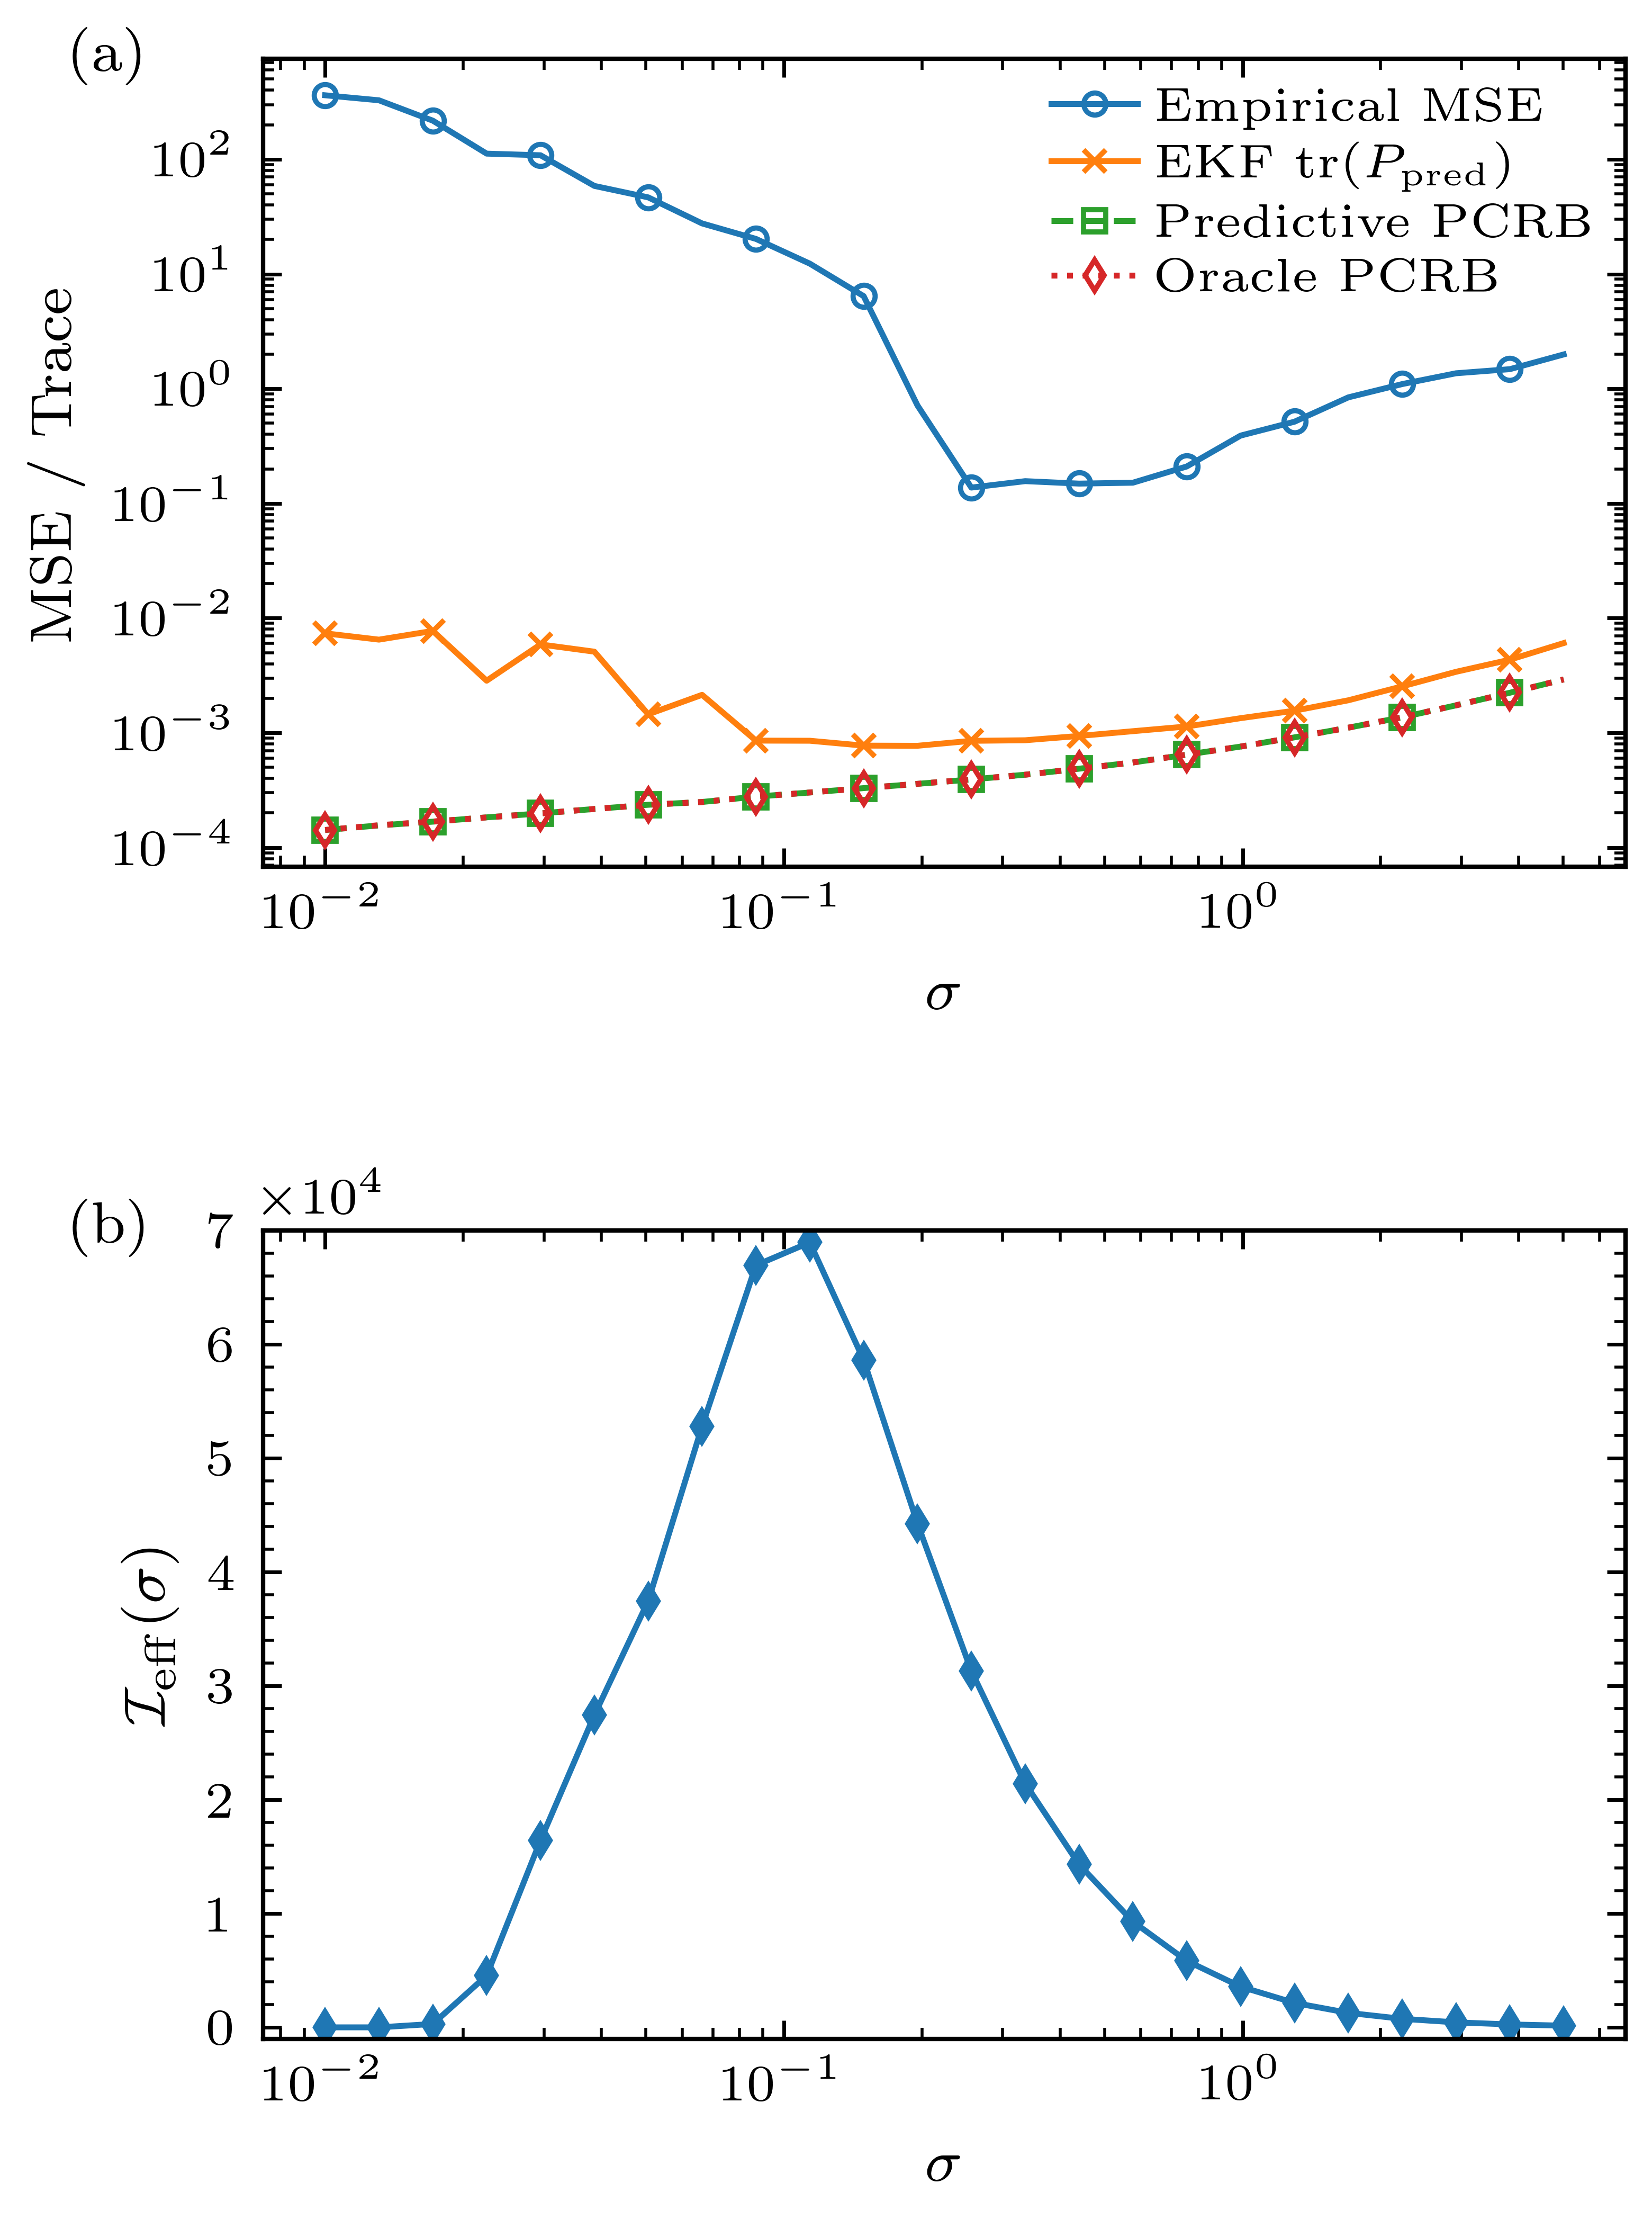

In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter, FixedLocator
import scienceplots


plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']

mpl.rcParams['figure.dpi']        = 1000
mpl.rcParams['axes.unicode_minus']= False
mpl.rcParams['axes.linewidth']    = 0.6      # 坐标轴更细
mpl.rcParams['xtick.labelsize']   = 7
mpl.rcParams['ytick.labelsize']   = 7
mpl.rcParams['axes.labelsize']    = 8
mpl.rcParams['legend.fontsize']   = 6.5
mpl.rcParams['lines.linewidth']   = 0.8      # 线更细
mpl.rcParams['lines.markersize']  = 3        # marker 更小
mpl.rcParams['xtick.major.width'] = 0.5
mpl.rcParams['ytick.major.width'] = 0.5
mpl.rcParams['xtick.minor.width'] = 0.4
mpl.rcParams['ytick.minor.width'] = 0.4
mpl.rcParams['xtick.major.size']  = 2.5
mpl.rcParams['ytick.major.size']  = 2.5
mpl.rcParams['xtick.minor.size']  = 1.5
mpl.rcParams['ytick.minor.size']  = 1.5

# 高度从 6 降到 4.4，整体更紧凑
fig, ax = plt.subplots(2, 1, figsize=(3.3, 4.4))

colors     = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
markers    = ['o', 'x', 's', 'd']
linestyles = ['-', '-', '--', ':']

# 如果你 sigmas 点数很多，让 marker 稀疏一些，避免拥挤
me = max(1, len(res.sigmas) // 10)   # 大约画 10 个 marker

# ----------------------------
# (a) 上图
# ----------------------------
ax[0].loglog(res.sigmas, res.steady_mse,      ls=linestyles[0], marker=markers[0], color=colors[0],
             markevery=me, markerfacecolor='none', markeredgewidth=0.7, label="Empirical MSE")
ax[0].loglog(res.sigmas, res.ekf_bound_trace, ls=linestyles[1], marker=markers[1], color=colors[1],
             markevery=me, markeredgewidth=0.7, label=r"EKF tr($P_{\mathrm{pred}}$)")
ax[0].loglog(res.sigmas, res.pcrb_trace,      ls=linestyles[2], marker=markers[2], color=colors[2],
             markevery=me, markerfacecolor='none', markeredgewidth=0.7, label="Predictive PCRB")
ax[0].loglog(res.sigmas, res.pcrb_oracle,     ls=linestyles[3], marker=markers[3], color=colors[3],
             markevery=me, markerfacecolor='none', markeredgewidth=0.7, label="Oracle PCRB")
ax[0].set_xlabel(r"$\sigma$")
ax[0].set_ylabel("MSE / Trace")
ax[0].legend(loc='upper right', frameon=False, borderaxespad=0.2,
             handlelength=1.8, labelspacing=0.25, handletextpad=0.4)
ax[0].text(-0.14, 1.04, '(a)', transform=ax[0].transAxes,
           fontsize=8, fontweight='bold', va='top')

# ----------------------------
# (b) 下图
# ----------------------------
ax[1].semilogx(res.sigmas, res.fisher_curve, ls='-', marker='d', color=colors[0],
               markersize=3.2, markeredgewidth=0.6,
               label=r"$\mathcal{I}_{\mathrm{eff}}(\sigma)$")
ax[1].set_xlabel(r"$\sigma$")
ax[1].set_ylabel(r"$\mathcal{I}_{\mathrm{eff}}(\sigma)$")

ax[1].set_ylim(-1000, 7e4)
ax[1].yaxis.set_major_locator(FixedLocator([0, 1e4, 2e4, 3e4, 4e4, 5e4, 6e4, 7e4]))
ax[1].ticklabel_format(axis='y', style='sci', scilimits=(4, 4), useMathText=True)
ax[1].yaxis.get_offset_text().set_fontsize(7)

ax[1].text(-0.14, 1.04, '(b)', transform=ax[1].transAxes,
           fontsize=8, fontweight='bold', va='top')

fig.subplots_adjust(left=0.18, right=0.96, top=0.95, bottom=0.10, hspace=0.45)

fig.savefig("D:/Fig1.eps", dpi=800, bbox_inches='tight')
plt.show()

In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
BD-EKF baseline benchmark -- PyTorch edition (batched, float64).

Redesigned from the author's NumPy script. Fixes relative to that script:

 1. Adaptive sigma (Step 1 of Algorithm 1). Default ADAPT_RULE='info':
    the CESR objective of Algorithm 1 (GH predictive average of F),
    line-searched as in realization (B). UNFLOORED, this objective is
    exactly the one the paper proves pathological when the predictive
    charges the threshold pre-image (Lemma le:sigmainv) and it pins
    sigma to the grid floor; bracketed below by the realization-(A)
    warm start it is well behaved (shipped defaults, B=10^3: RMSE
    0.131 deg, NEES 1.91 ~= n). The operational posterior-contraction
    alternative argmin_sigma tr P_k^+ is kept as ADAPT_RULE='trP'.
    Both variants are run and printed; only the ADAPT_RULE variant
    goes into the LaTeX table.
    Either line search is bracketed from below by the realization-(A)
    warm start sigma_A = C_WARM*max_i|dh_i/dtheta|*sqrt(P_tt): while
    the predictive spread of h straddles thresholds, the smoothing
    bandwidth stays at the spread scale (sigma* ~ sqrt(lambda_max P-),
    Theorem th:cesr(b)) -- this is also what keeps the linearization
    valid across the whole capture basin of this heavily aliased
    steering map (cos(pi*i*sin th) has many sidelobe basins; a myopic
    small sigma locks onto the wrong one during acquisition).
 2. Common random numbers. ONE frozen batch of trajectories and
    measurement noise is reused across the entire sigma sweep, and one
    across all estimators in the head-to-head (the NumPy script
    reseeded per sigma: every grid point saw different trajectories).
 3. UKF/CKF numerics. Symmetric eigh-based matrix square roots and a
    PSD projection after P = Pp - K Pzz K^T (the script's plain
    cholesky can fail on 1-bit channels when all sigma points quantize
    identically and P drifts indefinite). Joseph form for all
    EKF-type updates.
 4. Undithered baseline as the paper defines it: the weak derivative
    of sign() is 0 a.e. (Theorem th:diff), so H == 0, the gain is
    identically zero, and the filter runs open loop. (The script
    instead used the ANALOG Jacobian with a sign-mean innovation --
    a different, undocumented baseline.)
 5. The ideal analog ceiling reuses the SAME readout noise V as the
    1-bit channel (full pairing across rows).
 6. 9-node Gauss-Hermite (paper) instead of 5.
 7. Self-tests reproduce paper items V-A(i)-(ii): autograd vs analytic
    Bussgang gain at machine precision; autograd of the sign channel
    is identically zero.
 8. Diagnostics: in-sector fraction (the steering map cos(pi*i*sin th)
    is invariant under th -> pi - th, so trajectories crossing
    |th| = pi/2 make theta-RMSE ill-posed; the script's T=300 with
    th_dot=0.05 crossed endfire around k~254).
 9. Initialization protocol. The script's deterministic 0.2-rad init
    bias exceeds the fine-lobe half-width of this aliased steering
    map (~0.07 rad at i=15), so EVERY local filter -- the analog EKF
    included -- mode-locks in a wrong sidelobe basin while its
    covariance collapses (verified by per-step traces: lock rate 0.00
    at every k). Computational dither cannot fix this: sigma smooths
    the quantizer along the AMPLITUDE axis, g(h(th);sigma)~h(th)/sigma
    at large sigma, so the theta-oscillations of h survive at every
    sigma and no sigma schedule widens the capture basin. Global
    acquisition is outside the scope of every compared algorithm and
    of the paper's local assumptions (PE / uniform observability in
    th:cons). Default protocol is therefore a consistent prior shared
    by all rows: x0_hat ~ N(x0_true, P0) with
    P0 = diag(INIT_STD_TH^2, INIT_STD_OM^2); the table then measures
    what the theorems cover. Set LEGACY_BIASED_INIT=True to reproduce
    the old protocol.

CONFIG / PAPER SYNC. The manuscript currently states q_acc=1e-3,
B=10^3, sweep grid 80 pts in [1e-2, 5]; the previous NumPy run used
q_acc=1e-5, B=200, 20 pts in [10^-1.8, 1]. Defaults below: q_acc=1e-5
(in-sector trajectories; q_acc=1e-3 makes the state diffuse out of
(-pi/2, pi/2) within the horizon), B_FINAL=1000 and the 80-point paper
grid. Whatever you run, sync Sec. V and the table caption to it.

Usage:
    python bdekf_benchmark_torch.py            # full run
    python bdekf_benchmark_torch.py --smoke    # tiny shape/sanity run
"""

import argparse
import csv
import math
import sys
import time

import numpy as np
import torch

# ----------------------------------------------------------------- config
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float64
SEED_SWEEP = 20260612
SEED_FINAL = 20260613

N_SENSORS = 16
DT = 0.1
Q_ACC = 1e-5          # paper text currently says 1e-3 -- sync (see header)
R_OBS = 1e-4
T_STEPS = 200
BURN_IN = 80
X0_TRUE = (0.30, 0.05)
INIT_STD_TH = 0.03    # consistent prior: x0_hat ~ N(x0_true, P0); theta
INIT_STD_OM = 0.02    #   std 0.03 rad (~1.7 deg) sits inside the lobe
LEGACY_BIASED_INIT = False   # True: original deterministic 0.2-rad bias
X0_FILT = (0.10, 0.00)       # used only by the legacy protocol
P0_DIAG = 0.5                # used only by the legacy protocol

B_SWEEP = 200         # Monte-Carlo batch for the sigma sweep (Phase 1)
B_FINAL = 1000        # Monte-Carlo batch for the comparison table (Phase 2)
SWEEP_GRID = np.logspace(-2.0, math.log10(5.0), 80)   # paper grid
ADAPT_GRID = np.logspace(-2.0, math.log10(5.0), 25)   # Step-1 line search
ADAPT_RULE = "info"   # 'info' (Algorithm 1: CESR objective, (A)-floored) | 'trP'
C_WARM = 1.0          # realization (A) floor: sigma >= C*spread(h)
GH_N = 9
JITTER = 1e-12
PSD_FLOOR = 1e-14
SAVE_SWEEP_CSV = "bdekf_sweep.csv"
MAKE_PLOT = True      # writes bdekf_sweep.png/.eps if matplotlib available

torch.set_default_dtype(DTYPE)
SQRT2PI = math.sqrt(2.0 * math.pi)
RAD2DEG = 180.0 / math.pi

IDX = torch.arange(N_SENSORS, dtype=DTYPE, device=DEVICE)
F_MAT = torch.tensor([[1.0, DT], [0.0, 1.0]], dtype=DTYPE, device=DEVICE)
Q_MAT = Q_ACC * torch.tensor([[DT ** 3 / 3, DT ** 2 / 2],
                              [DT ** 2 / 2, DT]], dtype=DTYPE, device=DEVICE)
LQ = torch.linalg.cholesky(Q_MAT)
I2 = torch.eye(2, dtype=DTYPE, device=DEVICE)
IN = torch.eye(N_SENSORS, dtype=DTYPE, device=DEVICE)
_ghx, _ghw = np.polynomial.hermite.hermgauss(GH_N)      # physicists'
GH_X = torch.tensor(_ghx, dtype=DTYPE, device=DEVICE)
GH_W = torch.tensor(_ghw, dtype=DTYPE, device=DEVICE)

# ------------------------------------------------------------------ model
def h_of(th):                       # (...,) -> (..., N)
    return torch.cos(math.pi * IDX * torch.sin(th)[..., None])

def h_jac(th):                      # d h_i / d theta
    s = torch.sin(th)[..., None]
    c = torch.cos(th)[..., None]
    return -math.pi * IDX * c * torch.sin(math.pi * IDX * s)

def npdf(x):
    return torch.exp(-0.5 * x * x) / SQRT2PI

def ncdf(x):
    return torch.special.ndtr(x)

def g_smooth(u, s):                 # E_eta sign(u + eta), eta~N(0, s^2)
    return 2.0 * ncdf(u / s) - 1.0

def b_gain(u, s):                   # d g / d u  (analytic Bussgang gain)
    return (2.0 / s) * npdf(u / s)

# -------------------------------------------------------------- self-test
def self_tests():
    th = torch.tensor([0.27], dtype=DTYPE, device=DEVICE,
                      requires_grad=True)
    sg = 0.13
    g_smooth(h_of(th), sg).sum().backward()
    auto = th.grad.item()
    ana = (b_gain(h_of(th.detach()), sg) * h_jac(th.detach())).sum().item()
    err = abs(auto - ana)
    th2 = torch.tensor([0.27], dtype=DTYPE, device=DEVICE,
                       requires_grad=True)
    torch.sign(h_of(th2)).sum().backward()
    zg = th2.grad.abs().max().item()
    print(f"[self-test] |autograd - analytic Bussgang gain| = {err:.3e}"
          f"   (paper V-A item i)")
    print(f"[self-test] autograd of raw sign() channel      = {zg:.1e}"
          f"   (paper V-A item ii)")
    assert err < 1e-12 and zg == 0.0

# -------------------------------------------------------------- simulator
def simulate(B, seed):
    """Trajectories x (B,T,2), 1-bit measurements Z (B,T,N), noise V, shared filter init e0."""
    gen = torch.Generator(device=DEVICE)
    gen.manual_seed(seed)
    x = torch.empty(B, T_STEPS, 2, dtype=DTYPE, device=DEVICE)
    x[:, 0, 0] = X0_TRUE[0]
    x[:, 0, 1] = X0_TRUE[1]
    for k in range(1, T_STEPS):
        w = torch.randn(B, 2, 1, generator=gen, dtype=DTYPE, device=DEVICE)
        x[:, k] = x[:, k - 1] @ F_MAT.T + (LQ @ w).squeeze(-1)
    V = math.sqrt(R_OBS) * torch.randn(B, T_STEPS, N_SENSORS,
                                       generator=gen, dtype=DTYPE,
                                       device=DEVICE)
    Z = torch.sign(h_of(x[..., 0])) + V        # M2: raw 1-bit + readout
    if LEGACY_BIASED_INIT:
        e0 = torch.empty(B, 2, dtype=DTYPE, device=DEVICE)
        e0[:, 0], e0[:, 1] = X0_FILT[0], X0_FILT[1]
    else:
        stds = torch.tensor([INIT_STD_TH, INIT_STD_OM], dtype=DTYPE,
                            device=DEVICE)
        e0 = (x[:, 0] + stds
              * torch.randn(B, 2, generator=gen, dtype=DTYPE,
                            device=DEVICE))
    return x, Z, V, e0

# ---------------------------------------------------------- linear algebra
def msqrt(P):
    """Symmetric PSD square root, batched, eigh-based (robust)."""
    P = 0.5 * (P + P.transpose(-1, -2))
    w, Vc = torch.linalg.eigh(P)
    w = torch.clamp(w, min=PSD_FLOOR)
    return (Vc * w.sqrt().unsqueeze(-2)) @ Vc.transpose(-1, -2)

def psd_project(P):
    P = 0.5 * (P + P.transpose(-1, -2))
    w, Vc = torch.linalg.eigh(P)
    w = torch.clamp(w, min=PSD_FLOOR)
    return (Vc * w.unsqueeze(-2)) @ Vc.transpose(-1, -2)

def kalman_gain(Pp, H, r_eff):
    """K (B,2,N), S (B,N,N); r_eff is the diagonal (B,N)."""
    S = H @ Pp @ H.transpose(-1, -2) + torch.diag_embed(r_eff) + JITTER * IN
    K = torch.linalg.solve(S, H @ Pp).transpose(-1, -2)
    return K, S

def joseph(Pp, K, H, r_eff):
    A = I2 - K @ H
    P = (A @ Pp @ A.transpose(-1, -2)
         + (K * r_eff.unsqueeze(-2)) @ K.transpose(-1, -2))
    return 0.5 * (P + P.transpose(-1, -2))

# ----------------------------------------------------------------- filters
def _init(B, e0):
    e = torch.empty(B, T_STEPS, 2, dtype=DTYPE, device=DEVICE)
    e[:, 0] = e0
    if LEGACY_BIASED_INIT:
        P = (P0_DIAG * I2).expand(B, 2, 2).clone()
    else:
        P = torch.diag(torch.tensor([INIT_STD_TH ** 2, INIT_STD_OM ** 2],
                                    dtype=DTYPE, device=DEVICE)
                       ).expand(B, 2, 2).clone()
    nees = torch.zeros(B, dtype=DTYPE, device=DEVICE)
    return e, P, nees

def _nees_add(nees, k, x, e, P):
    if k >= BURN_IN:
        d = (x[:, k] - e[:, k]).unsqueeze(-1)
        nees += (d.transpose(-1, -2)
                 @ torch.linalg.solve(P, d)).squeeze(-1).squeeze(-1)
    return nees

def _finish(x, e, nees):
    err = (e[:, BURN_IN:, 0] - x[:, BURN_IN:, 0])
    rmse = RAD2DEG * torch.sqrt((err ** 2).mean(dim=1))
    return rmse.cpu().numpy(), (nees / (T_STEPS - BURN_IN)).cpu().numpy()

def run_openloop(x, Z, e0):
    """Undithered EKF: H = d sign/dx = 0 a.e. => K = 0 (paper Sec. II)."""
    B = x.shape[0]
    e, P, nees = _init(B, e0)
    for k in range(1, T_STEPS):
        e[:, k] = e[:, k - 1] @ F_MAT.T
        P = F_MAT @ P @ F_MAT.T + Q_MAT
        nees = _nees_add(nees, k, x, e, P)
    return _finish(x, e, nees)

def run_naive(x, Z, e0):
    """The NumPy script's 'undithered' variant: analog Jacobian with a
    sign-mean innovation. Not the paper's H=0 collapse (that is
    run_openloop) but a useful exhibit: it updates with an invalid
    gradient, so it is overconfident -- E[NEES] >> n."""
    B = x.shape[0]
    e, P, nees = _init(B, e0)
    for k in range(1, T_STEPS):
        xp = e[:, k - 1] @ F_MAT.T
        Pp = F_MAT @ P @ F_MAT.T + Q_MAT
        hp, jc = h_of(xp[:, 0]), h_jac(xp[:, 0])
        H = torch.zeros(B, N_SENSORS, 2, dtype=DTYPE, device=DEVICE)
        H[..., 0] = jc
        r_eff = torch.full_like(hp, R_OBS)
        K, _ = kalman_gain(Pp, H, r_eff)
        e[:, k] = xp + (K @ (Z[:, k] - torch.sign(hp))
                        .unsqueeze(-1)).squeeze(-1)
        P = joseph(Pp, K, H, r_eff)
        nees = _nees_add(nees, k, x, e, P)
    return _finish(x, e, nees)

def run_bussgang_fixed(x, Z, sigma, e0):
    """Fixed-sigma Bussgang-KF (jung2025-style at oracle-tuned sigma)."""
    B = x.shape[0]
    e, P, nees = _init(B, e0)
    for k in range(1, T_STEPS):
        xp = e[:, k - 1] @ F_MAT.T
        Pp = F_MAT @ P @ F_MAT.T + Q_MAT
        hp, jc = h_of(xp[:, 0]), h_jac(xp[:, 0])
        gp = g_smooth(hp, sigma)
        H = torch.zeros(B, N_SENSORS, 2, dtype=DTYPE, device=DEVICE)
        H[..., 0] = b_gain(hp, sigma) * jc
        r_eff = R_OBS + torch.clamp(1.0 - gp ** 2, min=1e-12)
        K, _ = kalman_gain(Pp, H, r_eff)
        e[:, k] = xp + (K @ (Z[:, k] - gp).unsqueeze(-1)).squeeze(-1)
        P = joseph(Pp, K, H, r_eff)
        nees = _nees_add(nees, k, x, e, P)
    return _finish(x, e, nees)

def _sigma_points(xp, Pp, scale, n_pts, w_m, w_c):
    S = msqrt(scale * Pp)                          # (B,2,2)
    cols = S.transpose(-1, -2)                     # rows are columns of S
    if n_pts == 5:                                 # UKF: m, m+-cols
        X = torch.cat([xp.unsqueeze(1),
                       xp.unsqueeze(1) + cols,
                       xp.unsqueeze(1) - cols], dim=1)
    else:                                          # CKF: m+-sqrt(n) cols
        X = torch.cat([xp.unsqueeze(1) + cols,
                       xp.unsqueeze(1) - cols], dim=1)
    return X

def _run_sp(x, Z, kind, e0):
    """Sigma-point filters on the RAW 1-bit channel (implicit dither)."""
    B = x.shape[0]
    n = 2
    if kind == "ukf":
        alpha, beta, kappa = 1.0, 2.0, 0.0
        lam = alpha ** 2 * (n + kappa) - n
        w_m = torch.full((5,), 1.0 / (2 * (n + lam)), dtype=DTYPE,
                         device=DEVICE)
        w_m[0] = lam / (n + lam)
        w_c = w_m.clone()
        w_c[0] += 1.0 - alpha ** 2 + beta
        scale, n_pts = n + lam, 5
    else:
        w_m = torch.full((4,), 0.25, dtype=DTYPE, device=DEVICE)
        w_c = w_m.clone()
        scale, n_pts = float(n), 4
    e, P, nees = _init(B, e0)
    for k in range(1, T_STEPS):
        xp = e[:, k - 1] @ F_MAT.T
        Pp = F_MAT @ P @ F_MAT.T + Q_MAT
        X = _sigma_points(xp, Pp, scale, n_pts, w_m, w_c)   # (B,np,2)
        Zp = torch.sign(h_of(X[..., 0]))                    # (B,np,N)
        zb = (w_m.view(1, -1, 1) * Zp).sum(dim=1)           # (B,N)
        dz = Zp - zb.unsqueeze(1)                           # (B,np,N)
        dx = X - xp.unsqueeze(1)                            # (B,np,2)
        Pzz = (R_OBS * IN
               + torch.einsum("p,bpi,bpj->bij", w_c, dz, dz)
               + JITTER * IN)
        Pxz = torch.einsum("p,bpi,bpj->bij", w_c, dx, dz)   # (B,2,N)
        K = torch.linalg.solve(Pzz, Pxz.transpose(-1, -2)).transpose(-1, -2)
        e[:, k] = xp + (K @ (Z[:, k] - zb).unsqueeze(-1)).squeeze(-1)
        P = psd_project(Pp - K @ Pzz @ K.transpose(-1, -2))
        nees = _nees_add(nees, k, x, e, P)
    return _finish(x, e, nees)

def run_ukf(x, Z, e0):
    return _run_sp(x, Z, "ukf", e0)

def run_ckf(x, Z, e0):
    return _run_sp(x, Z, "ckf", e0)

def _step1_trP(xp, Pp, sg):
    """Posterior-contraction scores: tr(Pp H'S^-1 H Pp) per sigma."""
    hp = h_of(xp[:, 0]).unsqueeze(1)               # (B,1,N)
    jc = h_jac(xp[:, 0]).unsqueeze(1)              # (B,1,N)
    s3 = sg.view(1, -1, 1)
    gp = 2.0 * ncdf(hp / s3) - 1.0                 # (B,Ns,N)
    Hc = (2.0 / s3) * npdf(hp / s3) * jc           # (B,Ns,N)
    re = R_OBS + torch.clamp(1.0 - gp ** 2, min=1e-12)
    H4 = torch.zeros(*Hc.shape, 2, dtype=DTYPE, device=DEVICE)
    H4[..., 0] = Hc
    Pp4 = Pp.unsqueeze(1)
    M = H4 @ Pp4                                   # (B,Ns,N,2)
    S = H4 @ Pp4 @ H4.transpose(-1, -2) + torch.diag_embed(re) \
        + JITTER * IN
    return (M * torch.linalg.solve(S, M)).sum(dim=(-1, -2))   # (B,Ns)

def _step1_info(xp, Pp, sg):
    """Raw predictive-information scores of eq:cesr (diagnostic option).
    Pathological when the predictive charges the threshold pre-image
    (Lemma le:sigmainv): tends to pin sigma at the grid floor here."""
    std = torch.sqrt(torch.clamp(Pp[:, 0, 0], min=1e-12))
    thn = xp[:, 0:1] + math.sqrt(2.0) * std.unsqueeze(1) * GH_X.view(1, -1)
    hh = h_of(thn)                                  # (B,G,N)
    jj = h_jac(thn)
    s4 = sg.view(1, 1, -1, 1)
    u = hh.unsqueeze(2) / s4                        # (B,G,Ns,N)
    p = npdf(u)
    Pc = ncdf(u)
    den = torch.clamp(Pc * (1.0 - Pc), min=1e-15)
    Fper = (jj.unsqueeze(2) ** 2 * p * p / den).sum(-1) / s4.squeeze(-1) ** 2
    return (Fper * GH_W.view(1, -1, 1)).sum(dim=1) / math.sqrt(math.pi)

def run_bdekf(x, Z, rule, e0):
    """BD-EKF, Algorithm 1. Step 1 = realizations (A)+(B) of Sec. III-B:
    a per-step line search over ADAPT_GRID (B), bracketed from below by
    the warm start sigma_A = C_WARM * max_i |dh_i/dtheta| * sqrt(P_tt)
    (A, sigma* ~ sqrt(lambda_max P-)): while the predictive spread of
    h still straddles thresholds, the smoothing bandwidth is kept at
    the spread scale, which is also what keeps the linearization valid
    over the whole capture basin during acquisition."""
    B = x.shape[0]
    sg = torch.tensor(ADAPT_GRID, dtype=DTYPE, device=DEVICE)
    Ns = sg.numel()
    e, P, nees = _init(B, e0)
    sig_log = torch.zeros(B, dtype=DTYPE, device=DEVICE)
    for k in range(1, T_STEPS):
        xp = e[:, k - 1] @ F_MAT.T
        Pp = F_MAT @ P @ F_MAT.T + Q_MAT
        scores = (_step1_trP if rule == "trP" else _step1_info)(xp, Pp, sg)
        jc = h_jac(xp[:, 0])                       # (B,N)
        sig_a = (C_WARM * jc.abs().max(dim=1).values
                 * torch.sqrt(torch.clamp(Pp[:, 0, 0], min=0.0)))
        idx = torch.searchsorted(sg, sig_a.clamp(max=sg[-1]).contiguous())
        idx = idx.clamp(max=Ns - 1)                # warm-start floor (A)
        mask = (torch.arange(Ns, device=DEVICE).unsqueeze(0)
                >= idx.unsqueeze(1))
        scores = torch.where(mask, scores,
                             torch.full_like(scores, -math.inf))
        pick = scores.argmax(dim=1)
        sk = sg[pick]                              # (B,)
        sig_log += sk
        hp = h_of(xp[:, 0])
        gp = g_smooth(hp, sk.unsqueeze(-1))
        H = torch.zeros(B, N_SENSORS, 2, dtype=DTYPE, device=DEVICE)
        H[..., 0] = b_gain(hp, sk.unsqueeze(-1)) * jc
        r_eff = R_OBS + torch.clamp(1.0 - gp ** 2, min=1e-12)
        K, _ = kalman_gain(Pp, H, r_eff)
        e[:, k] = xp + (K @ (Z[:, k] - gp).unsqueeze(-1)).squeeze(-1)
        P = joseph(Pp, K, H, r_eff)
        nees = _nees_add(nees, k, x, e, P)
    rmse, nm = _finish(x, e, nees)
    return rmse, nm, (sig_log / (T_STEPS - 1)).mean().item()

def run_ideal(x, V, e0):
    """Analog ceiling: EKF on z = h(x)+v, SAME readout noise V
    and the same consistent prior as every other row."""
    B = x.shape[0]
    e, P, nees = _init(B, e0)
    for k in range(1, T_STEPS):
        xp = e[:, k - 1] @ F_MAT.T
        Pp = F_MAT @ P @ F_MAT.T + Q_MAT
        hp, jc = h_of(xp[:, 0]), h_jac(xp[:, 0])
        H = torch.zeros(B, N_SENSORS, 2, dtype=DTYPE, device=DEVICE)
        H[..., 0] = jc
        r_eff = torch.full_like(hp, R_OBS)
        K, _ = kalman_gain(Pp, H, r_eff)
        za = h_of(x[:, k, 0]) + V[:, k]
        e[:, k] = xp + (K @ (za - hp).unsqueeze(-1)).squeeze(-1)
        P = joseph(Pp, K, H, r_eff)
        nees = _nees_add(nees, k, x, e, P)
    return _finish(x, e, nees)

# ------------------------------------------------------------------ phases
def phase1_sweep():
    print(f"\nPhase 1: fixed-sigma sweep ({len(SWEEP_GRID)} pts, "
          f"B={B_SWEEP}, common random numbers)")
    x, Z, _, e0 = simulate(B_SWEEP, SEED_SWEEP)
    insector(x)
    means, ses = [], []
    t0 = time.time()
    for i, s in enumerate(SWEEP_GRID):
        r, _ = run_bussgang_fixed(x, Z, float(s), e0)
        means.append(r.mean())
        ses.append(r.std(ddof=1) / math.sqrt(len(r)))
        if (i + 1) % 10 == 0:
            print(f"  {i + 1:3d}/{len(SWEEP_GRID)}  sigma={s:7.4f}  "
                  f"RMSE={means[-1]:7.3f} deg   ({time.time() - t0:.0f}s)")
            sys.stdout.flush()
    means, ses = np.array(means), np.array(ses)
    bi = int(np.argmin(means))
    best = float(SWEEP_GRID[bi])
    print(f"  best fixed sigma = {best:.4f}  "
          f"({means[bi]:.3f} +/- {ses[bi]:.3f} deg)")
    with open(SAVE_SWEEP_CSV, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["sigma", "rmse_mean_deg", "rmse_se_deg"])
        for s, m, e in zip(SWEEP_GRID, means, ses):
            w.writerow([f"{s:.6g}", f"{m:.6g}", f"{e:.6g}"])
    print(f"  sweep written to {SAVE_SWEEP_CSV}")
    if MAKE_PLOT:
        try:
            import matplotlib
            matplotlib.use("Agg")
            import matplotlib.pyplot as plt
            fig, ax = plt.subplots(figsize=(4.2, 3.0))
            ax.errorbar(SWEEP_GRID, means, yerr=ses, lw=1.2, capsize=2)
            ax.set_xscale("log")
            ax.set_xlabel(r"dither scale $\sigma$")
            ax.set_ylabel("steady-state RMSE (deg)")
            ax.axvline(best, ls="--", lw=0.8, color="k")
            fig.tight_layout()
            fig.savefig("bdekf_sweep.png", dpi=200)
            fig.savefig("bdekf_sweep.eps")
            print("  plot written to bdekf_sweep.png / .eps")
        except Exception as exc:                       # pragma: no cover
            print(f"  (plot skipped: {exc})")
    return best

def insector(x):
    frac = ((x[:, BURN_IN:, 0].abs() < math.pi / 2).all(dim=1)
            .to(DTYPE).mean().item())
    print(f"  in-sector fraction (|theta|<pi/2 over eval window): "
          f"{frac:.3f}" + ("" if frac > 0.95 else
                           "   << WARNING: theta<->pi-theta ambiguity "
                           "pollutes RMSE; shorten T or slow the truth"))
    return frac

def phase2_table(best_sigma):
    print(f"\nPhase 2: head-to-head (B={B_FINAL}, common trajectories)")
    x, Z, V, e0 = simulate(B_FINAL, SEED_FINAL)
    insector(x)
    t0 = time.time()
    out = {}
    out["und"] = run_openloop(x, Z, e0)
    out["naive"] = run_naive(x, Z, e0)
    out["bus"] = run_bussgang_fixed(x, Z, best_sigma, e0)
    out["ukf"] = run_ukf(x, Z, e0)
    out["ckf"] = run_ckf(x, Z, e0)
    r_t, n_t, s_t = run_bdekf(x, Z, "trP", e0)
    r_i, n_i, s_i = run_bdekf(x, Z, "info", e0)
    out["bde_trP"] = (r_t, n_t)
    out["bde_info"] = (r_i, n_i)
    out["ideal"] = run_ideal(x, V, e0)
    print(f"  filters done in {time.time() - t0:.0f}s")
    print(f"  mean adaptive sigma: trP-rule {s_t:.4f} | "
          f"info-rule {s_i:.4f} (grid floor {ADAPT_GRID[0]:.4f})")

    names = [("und", "Undithered EKF (H=0, open loop)"),
             ("naive", "Naive EKF (analog Jacobian, sign mean)"),
             ("bus", f"Bussgang-KF, best fixed sigma={best_sigma:.3f}"),
             ("ukf", "UKF (implicit dither)"),
             ("ckf", "CKF (implicit dither)"),
             ("bde_trP", "BD-EKF adaptive (trP rule)"),
             ("bde_info", "BD-EKF adaptive (info rule, diagnostic)"),
             ("ideal", "Ideal analog EKF (ceiling)")]
    print(f"\n  {'estimator':44s} {'RMSE(deg)':>12s} {'+/-se':>8s} "
          f"{'median':>8s} {'NEES':>10s}")
    for key, nm in names:
        r, n = out[key]
        se = r.std(ddof=1) / math.sqrt(len(r))
        print(f"  {nm:44s} {r.mean():12.3f} {se:8.3f} "
              f"{np.median(r):8.3f} {n.mean():10.2f}")

    bde_key = "bde_trP" if ADAPT_RULE == "trP" else "bde_info"
    rb = out[bde_key][0]
    for rival, nm in [("ukf", "UKF"), ("ckf", "CKF"),
                      ("bus", "Bussgang-KF(best)")]:
        d = out[rival][0] - rb
        rng = np.random.default_rng(0)
        bs = np.array([d[rng.integers(0, len(d), len(d))].mean()
                       for _ in range(10000)])
        lo, hi = np.percentile(bs, [2.5, 97.5])
        print(f"  paired vs {nm:18s}: mean diff {d.mean():+7.3f} deg, "
              f"95% CI [{lo:+.3f}, {hi:+.3f}], "
              f"win rate {(d > 0).mean():.2%}")

    rows = [("Undithered EKF (open loop)", out["und"][0]),
            (r"Na\"ive EKF (analog Jacobian)", out["naive"][0]),
            (r"Bussgang-KF~\cite{jung2025} (best $\sigma$)",
             out["bus"][0]),
            ("UKF (implicit dither)", out["ukf"][0]),
            ("CKF (implicit dither)", out["ckf"][0]),
            (r"\textbf{BD-EKF (adaptive $\sigma^\star$, "
             r"Alg.~\ref{alg:bdekf})}", rb),
            ("Ideal analog EKF (ceiling)", out["ideal"][0])]
    print("\n--- LaTeX table (paste over tab:baselines; "
          "sync caption + Sec. V text; keep whichever undithered "
          "row matches Sec. II) ---")
    print(r"\begin{table}[t]\centering")
    print(r"\caption{Steady-state RMSE (1-bit ULA, $N=%d$, $B=%d$, "
          r"Mode~M2, $q_{\mathrm{acc}}=10^{%d}$, %d-run mean)}"
          r"\label{tab:baselines}"
          % (N_SENSORS, B_FINAL, round(math.log10(Q_ACC)), B_FINAL))
    print(r"\begin{tabular}{@{}lc@{}}\toprule "
          r"Estimator & RMSE (deg) \\ \midrule")
    for nm, r in rows:
        val = r.mean()
        cell = (r"$\mathbf{%.2f}$" % val) if nm.startswith(r"\textbf") \
            else (r"$%.2f$" % val)
        print(r"%s & %s \\" % (nm, cell))
    print(r"\bottomrule\end{tabular}\end{table}")

# ------------------------------------------------------------------- main
def main():
    global B_SWEEP, B_FINAL, T_STEPS, BURN_IN, SWEEP_GRID, ADAPT_GRID
    ap = argparse.ArgumentParser()
    ap.add_argument("--smoke", action="store_true",
                    help="tiny run for shape/sanity checking")
    args, _ = ap.parse_known_args()   # ignore Jupyter's -f kernel.json
    if args.smoke:
        B_SWEEP, B_FINAL, T_STEPS, BURN_IN = 16, 32, 60, 20
        SWEEP_GRID = np.logspace(-2.0, math.log10(5.0), 8)
        ADAPT_GRID = np.logspace(-2.0, math.log10(2.0), 8)
    print(f"device={DEVICE}, dtype=float64, B_sweep={B_SWEEP}, "
          f"B_final={B_FINAL}, T={T_STEPS}, burn-in={BURN_IN}, "
          f"q_acc={Q_ACC:g}, r_obs={R_OBS:g}, ADAPT_RULE={ADAPT_RULE}, "
          f"C_WARM={C_WARM:g}")
    print("init: " + ("LEGACY deterministic bias (0.1, 0.0), P0=0.5*I"
                      if LEGACY_BIASED_INIT else
                      f"consistent prior, std=({INIT_STD_TH:g}, "
                      f"{INIT_STD_OM:g}) rad, shared across filters"))
    print("Channel: Mode M2 (raw 1-bit + readout noise; "
          "computational dither in the filter).")
    self_tests()
    best = phase1_sweep()
    phase2_table(best)

if __name__ == "__main__":
    main()

device=cuda, dtype=float64, B_sweep=200, B_final=1000, T=200, burn-in=80, q_acc=1e-05, r_obs=0.0001, ADAPT_RULE=info, C_WARM=1
init: consistent prior, std=(0.03, 0.02) rad, shared across filters
Channel: Mode M2 (raw 1-bit + readout noise; computational dither in the filter).
[self-test] |autograd - analytic Bussgang gain| = 2.842e-14   (paper V-A item i)
[self-test] autograd of raw sign() channel      = 0.0e+00   (paper V-A item ii)

Phase 1: fixed-sigma sweep (80 pts, B=200, common random numbers)
  in-sector fraction (|theta|<pi/2 over eval window): 0.945   << WARNING: theta<->pi-theta ambiguity pollutes RMSE; shorten T or slow the truth
   10/80  sigma= 0.0203  RMSE= 72.863 deg   (4s)
   20/80  sigma= 0.0446  RMSE= 18.972 deg   (7s)
   30/80  sigma= 0.0979  RMSE= 10.123 deg   (10s)
   40/80  sigma= 0.2150  RMSE=  0.185 deg   (14s)
   50/80  sigma= 0.4721  RMSE=  0.341 deg   (17s)
   60/80  sigma= 1.0368  RMSE=  0.626 deg   (21s)
   70/80  sigma= 2.2768  RMSE=  0.901 deg   (24s)
   